In [1]:
import os
from pathlib import Path

current_path = Path.cwd()
if str(current_path.name) == 'examples':
    os.chdir(current_path.parent)
print(Path.cwd())

/hkfs/home/haicore/hgf_hmgu/hgf_sfs7789/git/group-cl


In [2]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from groupcl.models import encoder
from groupcl.models import dynamics
from groupcl.models import groups
from groupcl import criterions
from groupcl import solver as solvers
from groupcl import datasets
from groupcl import loader as loaders
from groupcl.experiments import Experiment
from groupcl.utils import temperature_scheduler as scheduler
from groupcl.utils import rotation_matrix as rotation_sampler

In [3]:

behavior_variable_key = [
    # "time",
    "position",
    "direction_left",
    "direction_right",
]
bin_sizes = [
    # 5.0,
    # 1.6 / 10_000,
    0.01,
    None,
    None,
]
group_action_dims = [0]
content_dims = [1,2]

dataset = datasets.HippcampusRatDataset(
    name="achilles",
    # name="buddy",
    # name="gatsby",
    time_delayed_step=1,
    time_delayed_num_steps=9,
    behavior_variable_key = behavior_variable_key,
)

In [4]:
time_slice = slice(0, 1000)
time_slice = slice(0, len(dataset))
neural_data = dataset.observed_variable[time_slice].cpu()
position_data = dataset._data["position"][time_slice].cpu()

direction_right = dataset._cebra_dataset.continuous_index[time_slice, 1].cpu()
direction_left = dataset._cebra_dataset.continuous_index[time_slice, 2].cpu()
time_index = np.arange(neural_data.shape[0])

# Get trial data for the time slice
trial_id = dataset._data["trial_id"][time_slice].cpu()

neural_data.shape, position_data.shape, direction_right.shape, direction_left.shape, time_index.shape


(torch.Size([10169, 1200]),
 torch.Size([10169]),
 torch.Size([10169]),
 torch.Size([10169]),
 (10169,))

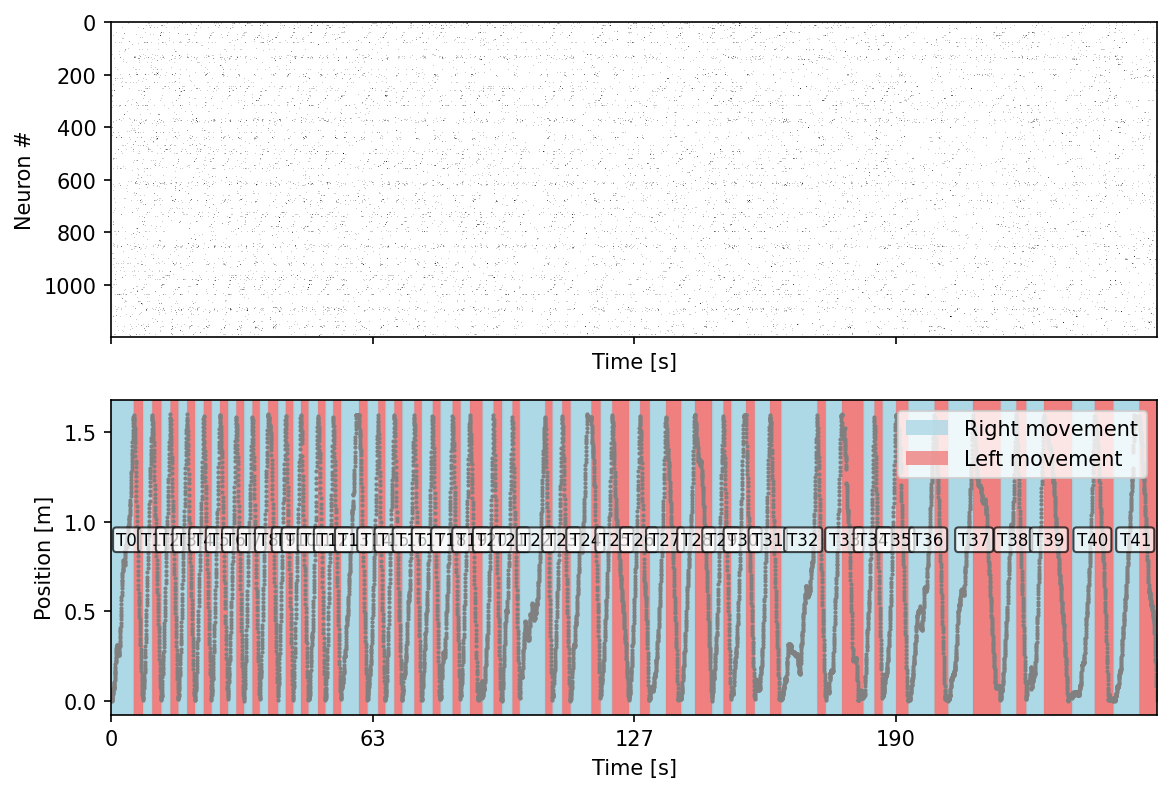

In [5]:
fig, (ax, ax2) = plt.subplots(2, 1, figsize=(9, 6), dpi=150, sharex=True)
plt.subplots_adjust(wspace=0.3)
ax.imshow(neural_data.T, aspect='auto', cmap='gray_r', interpolation='none')
ax.set_ylabel('Neuron #')
ax.set_xlabel('Time [s]')

tick_step = 5
sampling_rate = 40
tick_positions = np.linspace(0, len(time_index), tick_step)
tick_labels = np.linspace(0, len(time_index) / sampling_rate, tick_step)
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels.astype(int))


# Color background based on direction
for i in range(len(time_index) - 1):
    if direction_right[i] == 1:
        ax2.axvspan(time_index[i],
                    time_index[i + 1],
                    alpha=0.2,
                    color='lightblue',
                    zorder=0)
    elif direction_left[i] == 1:
        ax2.axvspan(time_index[i],
                    time_index[i + 1],
                    alpha=0.2,
                    color='lightcoral',
                    zorder=0)

# Add trial labels at the top
trial_changes = torch.where(trial_id[1:] != trial_id[:-1])[0] + 1
trial_starts = torch.cat([torch.tensor([0]), trial_changes])
trial_ends = torch.cat([trial_changes, torch.tensor([len(trial_id)])])

for start, end in zip(trial_starts, trial_ends):
    trial = trial_id[start].item()
    mid_point = (start + end) / 2
    ax2.text(mid_point, ax2.get_ylim()[1] * 0.95, f'T{trial}', 
             ha='center', va='top', fontsize=8, 
             bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

ax2.scatter(time_index, position_data, c='gray', s=1)
ax2.set_ylabel('Position [m]')
ax2.set_xlabel('Time [s]')
# ax2.set_xticks(np.linspace(0, 1000, 5))
# ax2.set_xticklabels(np.linspace(0, 0.025 * 1000, 5, dtype=int))
# Add legend for direction colors
from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor='lightblue', alpha=0.8, label='Right movement'),
    Patch(facecolor='lightcoral', alpha=0.8, label='Left movement')
]
ax2.legend(handles=legend_elements, loc='upper right')

plt.show()

In [6]:
dynamics_dim = 2
content_dim = 1
latent_dim = dynamics_dim + content_dim

batch_size = 2**10
batch_size_neg = 2**13
samples_per_action = dynamics_dim * 4

loader = loaders.BehaviorEquivariantDataLoaderV3(
    batch_size=batch_size,
    batch_size_neg=batch_size_neg,
    bin_sizes=bin_sizes,
    group_action_dims=group_action_dims,
    content_dims=content_dims,
    samples_per_action=samples_per_action,
    negative_distribution="both",
)

loss = criterions.SymmetricGCLLoss(
    group_model=groups.GroupDynamicsModel(
        system_solver=groups.LeastSquaresSolver(orthogonal_solution=False),
        dynamics_dim=dynamics_dim,
        no_grad_solve=False,
    ),
    criterion=criterions.MseInfoNCE(
        temperature=1.0,
        infonce_type="infonce_full_denominator",
    ),
)

model = encoder.MLP(
    input_dim=dataset.observed_dim,
    output_dim=latent_dim,
    hidden_dim=128,
    num_layers=3,
    normalize=False,
)

# assert dataset.time_delayed_num_steps + 1 == 10
# model = encoder.CebraModel(
#     architecture="offset10-model-mse",
#     input_dim=dataset.observed_dim,
#     output_dim=latent_dim,
#     hidden_dim=128,
# )

solver = solvers.GCLSolver(
    # seed=seed,
    silence_metric_errors=True,
    num_epochs=None,
    # max_iterations=20_000,
    max_iterations=5_000,
    optimizer=solvers.optim.AdamOptimizer(learning_rate=3e-4,),
    model=model,
    loss=loss,
)

val_test_loader = loader.clone()
# replace batch_size_neg with batch_size
val_test_loader.batch_size = 2**8
val_test_loader.batch_size_neg = val_test_loader.batch_size
val_test_loader.shuffle = False

exp = Experiment(
    dataset=dataset,
    solver=solver,
    dataset_split=datasets.splits.CebraRatSplit(),
    train_loader=loader,
    val_loader=val_test_loader.clone(),
    test_loader=val_test_loader.clone(),
)

No downsampling. Using all 46,895,104 pairs
Before filtering:
	Number of unique group factors: 319
	Number of pairs: 23961650
After filtering:
	Number of unique group factors: 319
	Number of pairs: 23961650


/hkfs/home/haicore/hgf_hmgu/hgf_sfs7789/git/group-cl/groupcl/utils/behavior.py:420: UserWarning: torch.searchsorted(): input value tensor is non-contiguous, this will lower the performance due to extra data copy when converting non-contiguous tensor to contiguous, please use contiguous input value tensor if possible. This message will only appear once per program. (Triggered internally at /pytorch/aten/src/ATen/native/BucketizationUtils.h:32.)
  discretized = torch.bucketize(variable, boundaries, right=True, out_int32=True)


No downsampling. Using all 3,059,001 pairs
Before filtering:
	Number of unique group factors: 319
	Number of pairs: 1557113
After filtering:
	Number of unique group factors: 319
	Number of pairs: 1557113
No downsampling. Using all 2,471,184 pairs
Before filtering:
	Number of unique group factors: 319
	Number of pairs: 1236314
After filtering:
	Number of unique group factors: 319
	Number of pairs: 1236314


In [7]:

from functools import partial

from groupcl.metrics.decoding import (
    DirectionKNNClassification,
    DirectionLogisticRegression,
    LinearPositionPrediction,
    PositionKNNRegression,
    PositionLinearRegression,
)
# reset val_metrics
train_metrics = []
for subspace in [None]:
    for method in [
        PositionKNNRegression,
        DirectionKNNClassification,
    ]:
        metric = method(subspace=subspace)
        train_metrics.append(metric)

In [8]:
exp.run(
    disable_jaxtyping=True,
    eval_frequency=1000,
    eval_kwargs=dict(metrics=train_metrics),
)

Training on device: cuda
Training with random seed: 42


Training:   0%|          | 0/5000 [00:00<?, ?iter/s]

Computing metric PositionDecoding_KNNRegression3
Computing metric DirectionDecoding_KNNClassification3
Computing metric PositionDecoding_KNNRegression3
Computing metric DirectionDecoding_KNNClassification3
Computing metric PositionDecoding_KNNRegression3
Computing metric DirectionDecoding_KNNClassification3
Computing metric PositionDecoding_KNNRegression3
Computing metric DirectionDecoding_KNNClassification3
Computing metric PositionDecoding_KNNRegression3
Computing metric DirectionDecoding_KNNClassification3
Computing metric PositionDecoding_KNNRegression3
Computing metric DirectionDecoding_KNNClassification3


In [9]:



partial_metrics = [
    partial(
        LinearPositionPrediction,
        prediction_step_size=step_size,
        prediction_steps_ahead=steps_ahead,
        groupby=groupby,
        max_eval_samples=500,
        max_train_samples=500,
    )
    for groupby in [None, "direction"]
    for (step_size, steps_ahead) in [
        # (0.1, 5),
        (0.05, 5),
        # (0.01, 50),
    ]
]
# reset val_metrics
val_metrics = []
for subspace in [None, "group", "content"]:
    for method in [
        PositionKNNRegression,
        PositionLinearRegression,
        DirectionKNNClassification,
        DirectionLogisticRegression,
    ] + partial_metrics:
        metric = method(subspace=subspace)
        val_metrics.append(metric)

In [10]:
import contextlib
import sys
import os

# Suppress all output including print, logs, and tqdm
with contextlib.redirect_stdout(open(os.devnull, 'w')), \
     contextlib.redirect_stderr(open(os.devnull, 'w')):
    train_results = exp.evaluate_train(metrics=val_metrics)
    val_results = exp.evaluate_val(metrics=val_metrics)
    test_results = exp.evaluate_test(metrics=val_metrics)

from dj_ml_core.utils import flatten_dict

train_results = flatten_dict(train_results, sep=".")
val_results = flatten_dict(val_results, sep=".")
test_results = flatten_dict(test_results, sep=".")

train_results = {
    k.replace("KNNRegression_", "KNNRegression"): v
    for k, v in train_results.items()
}
val_results = {
    k.replace("KNNRegression_", "KNNRegression"): v
    for k, v in val_results.items()
}
test_results = {
    k.replace("KNNRegression_", "KNNRegression"): v
    for k, v in test_results.items()
}


In [11]:
import pandas as pd
import numpy as np
# Filter for decoding metrics only
decoding_metrics = {k: v for k, v in test_results.items() if 'Decoding' in k}
train_decoding_metrics = {
    k: v for k, v in train_results.items() if 'Decoding' in k
}
val_decoding_metrics = {k: v for k, v in val_results.items() if 'Decoding' in k}


# Parse metric names to extract components
def parse_metric_name(metric_name):
    # Split on '.' to separate method from metric type (r2, median_err, mean_err, accuracy)
    if '.' in metric_name:
        base_name, metric_type = metric_name.split('.', 1)
    else:
        base_name = metric_name
        metric_type = None

    parts = base_name.split('_')

    # Extract target variable (first part before 'Decoding')
    target = parts[0].replace('Decoding', '')

    # Determine source (fromGroup, fromContent, or default)
    if 'fromGroup' in metric_name:
        source = 'fromGroup'
        # Remove fromGroup from parts to get method
        parts = [p for p in parts if p != 'fromGroup']
    elif 'fromContent' in metric_name:
        source = 'fromContent'
        # Remove fromContent from parts to get method
        parts = [p for p in parts if p != 'fromContent']
    else:
        source = 'default'

    # Extract method (last part after removing target and source)
    method = parts[-1]

    return target, method, source, metric_type


# Organize data with train/val/test as separate rows
data = []
for metric_name, test_value in decoding_metrics.items():
    target, method, source, metric_type = parse_metric_name(metric_name)
    train_value = train_decoding_metrics.get(metric_name, np.nan)
    val_value = val_decoding_metrics.get(metric_name, np.nan)

    # Add test row
    data.append({
        'metric': metric_name,
        'target': target,
        'method': method,
        'source': source,
        'metric_type': metric_type,
        'metric_value': test_value,
        'split': 'test'
    })

    # Add val row
    data.append({
        'metric': metric_name,
        'target': target,
        'method': method,
        'source': source,
        'metric_type': metric_type,
        'metric_value': val_value,
        'split': 'val'
    })

    # Add train row
    data.append({
        'metric': metric_name,
        'target': target,
        'method': method,
        'source': source,
        'metric_type': metric_type,
        'metric_value': train_value,
        'split': 'train'
    })

df = pd.DataFrame(data)

# let's filter out any _err metric_type for the TimeIndex target
df = df[~((df['target'] == 'TimeIndex') &
          (df['metric_type'].str.endswith('_err')))]

df

,metric,target,method,source,metric_type,metric_value,split
0,PositionDecoding_KNNRegression3.r2,Position,KNNRegression3,default,r2,0.824765,test
1,PositionDecoding_KNNRegression3.r2,Position,KNNRegression3,default,r2,0.832438,val
2,PositionDecoding_KNNRegression3.r2,Position,KNNRegression3,default,r2,0.999942,train
3,PositionDecoding_KNNRegression3.median_err,Position,KNNRegression3,default,median_err,0.075461,test
4,PositionDecoding_KNNRegression3.median_err,Position,KNNRegression3,default,median_err,0.082212,val
...,...,...,...,...,...,...,...
67,DirectionDecoding_fromContent_KNNClassificatio...,Direction,KNNClassification3,fromContent,accuracy,0.870857,val
68,DirectionDecoding_fromContent_KNNClassificatio...,Direction,KNNClassification3,fromContent,accuracy,1.000000,train
69,DirectionDecoding_fromContent_LogisticRegressi...,Direction,LogisticRegression,fromContent,accuracy,0.900763,test
70,DirectionDecoding_fromContent_LogisticRegressi...,Direction,LogisticRegression,fromContent,accuracy,0.900571,val


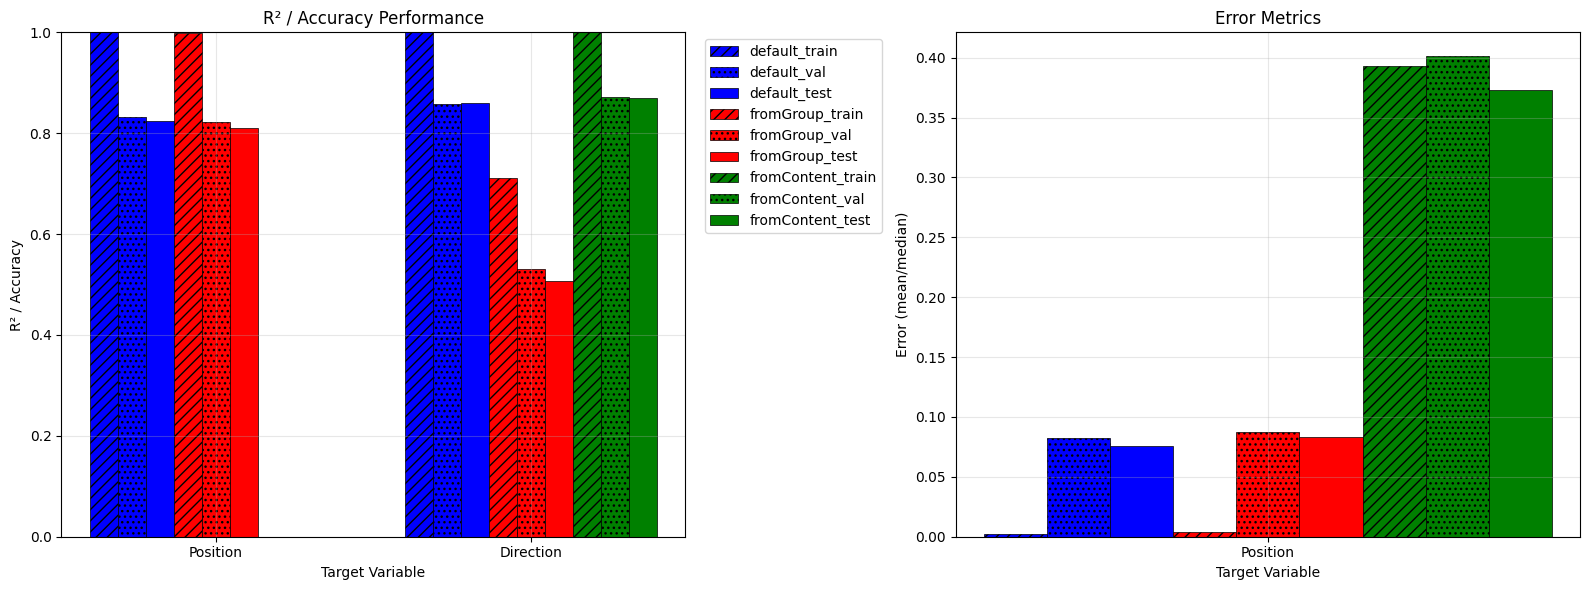

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Filter for only KNN methods
df_knn = df[df['method'].isin(['KNNRegression3', 'KNNClassification3'])]

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Get unique targets and splits
targets = ['Position', 'Direction']
splits = ['train', 'val', 'test']
sources = ['default', 'fromGroup', 'fromContent']

# Color mapping for sources and hatching patterns for splits
source_colors = {'default': 'blue', 'fromGroup': 'red', 'fromContent': 'green'}
split_hatches = {'train': '///', 'val': '...', 'test': None}  # Different hatching patterns

# Calculate positions for grouped bars
n_groups = len(targets)
n_bars_per_group = len(sources) * len(splits)
bar_width = 0.8 / n_bars_per_group
x_positions = np.arange(n_groups)

# Plot R²/Accuracy data (left subplot)
for i, target in enumerate(targets):
    for j, source in enumerate(sources):
        for k, split in enumerate(splits):
            # Calculate bar position
            offset = (j * len(splits) + k - (n_bars_per_group - 1) / 2) * bar_width
            x_pos = i + offset
            
            # Get data for r2/accuracy
            r2_data = df_knn[(df_knn['target'] == target) & 
                            (df_knn['source'] == source) & 
                            (df_knn['split'] == split) & 
                            (df_knn['metric_type'] == 'r2')]
            
            accuracy_data = df_knn[(df_knn['target'] == target) & 
                                  (df_knn['source'] == source) & 
                                  (df_knn['split'] == split) & 
                                  (df_knn['metric_type'] == 'accuracy')]
            
            # Plot r2/accuracy
            if len(r2_data) > 0:
                value = r2_data['metric_value'].iloc[0]
                ax1.bar(x_pos, value, bar_width, 
                       color=source_colors[source], 
                       hatch=split_hatches[split],
                       edgecolor='black',
                       linewidth=0.5,
                       label=f'{source}_{split}' if i == 0 else "")
            elif len(accuracy_data) > 0:
                value = accuracy_data['metric_value'].iloc[0]
                ax1.bar(x_pos, value, bar_width, 
                       color=source_colors[source], 
                       hatch=split_hatches[split],
                       edgecolor='black',
                       linewidth=0.5,
                       label=f'{source}_{split}' if i == 0 else "")

# Plot Error data (right subplot) - only for Position target
error_targets = ['Position']  # Only include Position for error metrics
error_x_positions = np.arange(len(error_targets))

for i, target in enumerate(error_targets):
    for j, source in enumerate(sources):
        for k, split in enumerate(splits):
            # Calculate bar position
            offset = (j * len(splits) + k - (n_bars_per_group - 1) / 2) * bar_width
            x_pos = i + offset
            
            # Get data for error metrics
            error_data = df_knn[(df_knn['target'] == target) & 
                               (df_knn['source'] == source) & 
                               (df_knn['split'] == split) & 
                               (df_knn['metric_type'].isin(['mean_err', 'median_err']))]
            
            if len(error_data) > 0:
                value = error_data['metric_value'].iloc[0]
                ax2.bar(x_pos, value, bar_width, 
                       color=source_colors[source], 
                       hatch=split_hatches[split],
                       edgecolor='black',
                       linewidth=0.5,
                       label=f'{source}_{split}' if i == 0 else "")

# Customize left subplot (R²/Accuracy)
ax1.set_xlabel('Target Variable')
ax1.set_ylabel('R² / Accuracy')
ax1.set_ylim(0, 1)
ax1.set_xticks(x_positions)
ax1.set_xticklabels(targets)
ax1.grid(True, alpha=0.3)
ax1.set_title('R² / Accuracy Performance')

# Customize right subplot (Error)
ax2.set_xlabel('Target Variable')
ax2.set_ylabel('Error (mean/median)')
ax2.set_xticks(error_x_positions)
ax2.set_xticklabels(error_targets)
ax2.grid(True, alpha=0.3)
ax2.set_title('Error Metrics')

# Set right y-axis range based on data
error_values = df_knn[df_knn['metric_type'].isin(['mean_err', 'median_err'])]['metric_value']
# if len(error_values) > 0:
#     ax2.set_ylim(0, 0.15)

# Add legend to the first subplot
handles, labels = ax1.get_legend_handles_labels()
if handles:
    ax1.legend(handles, labels, loc='upper left', bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.show()


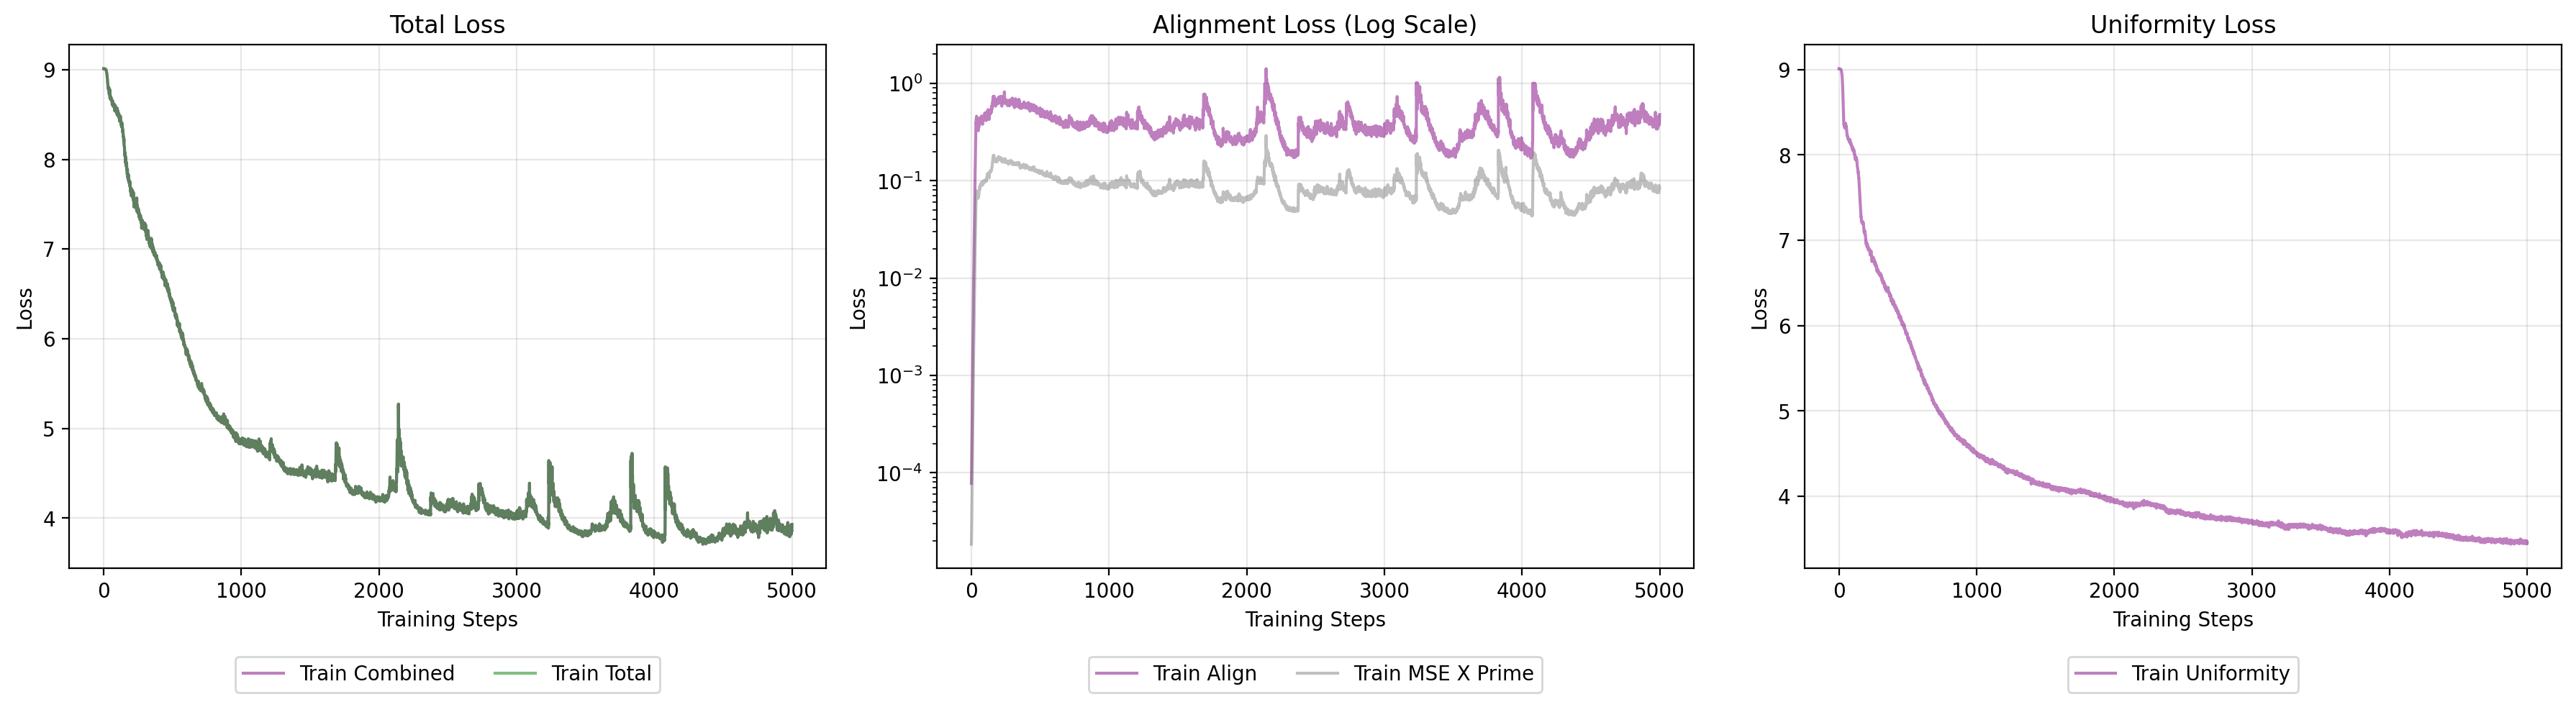

In [13]:
import matplotlib.pyplot as plt

# Configuration variables for styling
FIGSIZE = (18, 5)
TRAIN_COLOR = 'blue'
VAL_COLOR = 'blue'
CONTENT_COLOR = 'green'
GROUP_COLOR = 'red'
COMBINED_COLOR = 'purple'
MSE_COLOR = 'gray'

# Alpha and line style settings
TRAIN_ALPHA = 0.5
VAL_ALPHA = 0.9
TRAIN_STYLE = '-'
VAL_STYLE = '--'
TRAIN_WIDTH = 1.5
VAL_WIDTH = 2.5
GRID_ALPHA = 0.3
USE_LOG_SCALE = True  # Option to use log scale for y-axis

# Create a figure with 3 subplots for different loss types
fig, axes = plt.subplots(1, 3, figsize=FIGSIZE, sharey=False, dpi=200)
train_steps = range(len(exp.solver.logs.get('train_loss', [])))

# Define plot configurations for each subplot
subplot_configs = [
    # Subplot 1: Total Loss
    {
        'ax_idx':
            0,
        'title':
            'Total Loss',
        'log_scale':
            False,  # Normal scale for total loss
        'traces': [
            {
                'key': 'train_loss',
                'color': COMBINED_COLOR,
                'style': TRAIN_STYLE,
                'label': 'Train Combined',
                'alpha': TRAIN_ALPHA,
                'linewidth': TRAIN_WIDTH
            },
            {
                'key': 'train_loss_total',
                'color': CONTENT_COLOR,
                'style': TRAIN_STYLE,
                'label': 'Train Total',
                'alpha': TRAIN_ALPHA,
                'linewidth': TRAIN_WIDTH
            },
        ]
    },
    # Subplot 2: Alignment Loss
    {
        'ax_idx':
            1,
        'title':
            'Alignment Loss (Log Scale)',
        'log_scale':
            True,  # Use log scale for alignment loss
        'traces': [
            {
                'key': 'train_loss_align',
                'color': COMBINED_COLOR,
                'style': TRAIN_STYLE,
                'label': 'Train Align',
                'alpha': TRAIN_ALPHA,
                'linewidth': TRAIN_WIDTH
            },
            {
                'key': 'train_mse_x_prime_pred',
                'color': MSE_COLOR,
                'style': TRAIN_STYLE,
                'label': 'Train MSE X Prime',
                'alpha': TRAIN_ALPHA,
                'linewidth': TRAIN_WIDTH
            },
        ]
    },
    # Subplot 3: Uniformity Loss
    {
        'ax_idx':
            2,
        'title':
            'Uniformity Loss',
        'log_scale':
            False,  # Normal scale for uniformity loss
        'traces': [{
            'key': 'train_loss_uniformity',
            'color': COMBINED_COLOR,
            'style': TRAIN_STYLE,
            'label': 'Train Uniformity',
            'alpha': TRAIN_ALPHA,
            'linewidth': TRAIN_WIDTH
        },]
    }
]

# Generate each subplot
for config in subplot_configs:
    ax = axes[config['ax_idx']]

    # Add each trace if the key exists in logs
    for trace in config['traces']:
        if trace['key'] in exp.solver.logs:
            # Get the data
            y_data = exp.solver.logs[trace['key']]

            # Check if data is empty
            if len(y_data) == 0:
                print(f"Warning: {trace['key']} has no data")
                continue

            # Use train_steps for x data
            x_data = train_steps

            # Make sure x and y have the same length
            if len(x_data) != len(y_data):
                print(
                    f"Warning: {trace['key']} has different lengths for x ({len(x_data)}) and y ({len(y_data)})"
                )
                continue

            # Plot with specified parameters
            plot_kwargs = {
                'color': trace['color'],
                'linestyle': trace['style'],
                'label': trace['label'],
                'alpha': trace['alpha'],
                'linewidth': trace['linewidth']
            }

            ax.plot(x_data, y_data, **plot_kwargs)
        else:
            print(f"Warning: {trace['key']} not found in logs")
    # Set labels and styling
    ax.set_xlabel('Training Steps')
    ax.set_ylabel('Loss')
    ax.set_title(config['title'])
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)
    ax.grid(True, alpha=GRID_ALPHA)

    # Apply log scale if specified for this subplot
    if USE_LOG_SCALE and config.get('log_scale', False):
        ax.set_yscale('log')

plt.tight_layout()
plt.subplots_adjust(bottom=0.2)  # Make room for the baseline legend
plt.show()

In [14]:
neural_data = exp.dataset.observed_variable
behavior_data = exp.dataset.behavior_variable

direction_right = exp.dataset._cebra_dataset.continuous_index[:, 1]
direction_left = exp.dataset._cebra_dataset.continuous_index[:, 2]
neural_data.shape, neural_data.device, behavior_data.shape, behavior_data.device

(torch.Size([10169, 1200]),
 device(type='cpu'),
 torch.Size([10169, 3]),
 device(type='cpu'))

In [15]:
embs = exp.solver.embeddings(neural_data.to("cuda"))
embs.shape

torch.Size([10169, 3])

In [16]:
with torch.no_grad():
    # Get embeddings
    train_data = exp.train_data._data
    emb_train = exp.solver.embeddings(train_data["neural"])
    val_data = exp.val_data._data
    emb_val = exp.solver.embeddings(val_data["neural"])
    test_data = exp.test_data._data
    emb_test = exp.solver.embeddings(test_data["neural"])


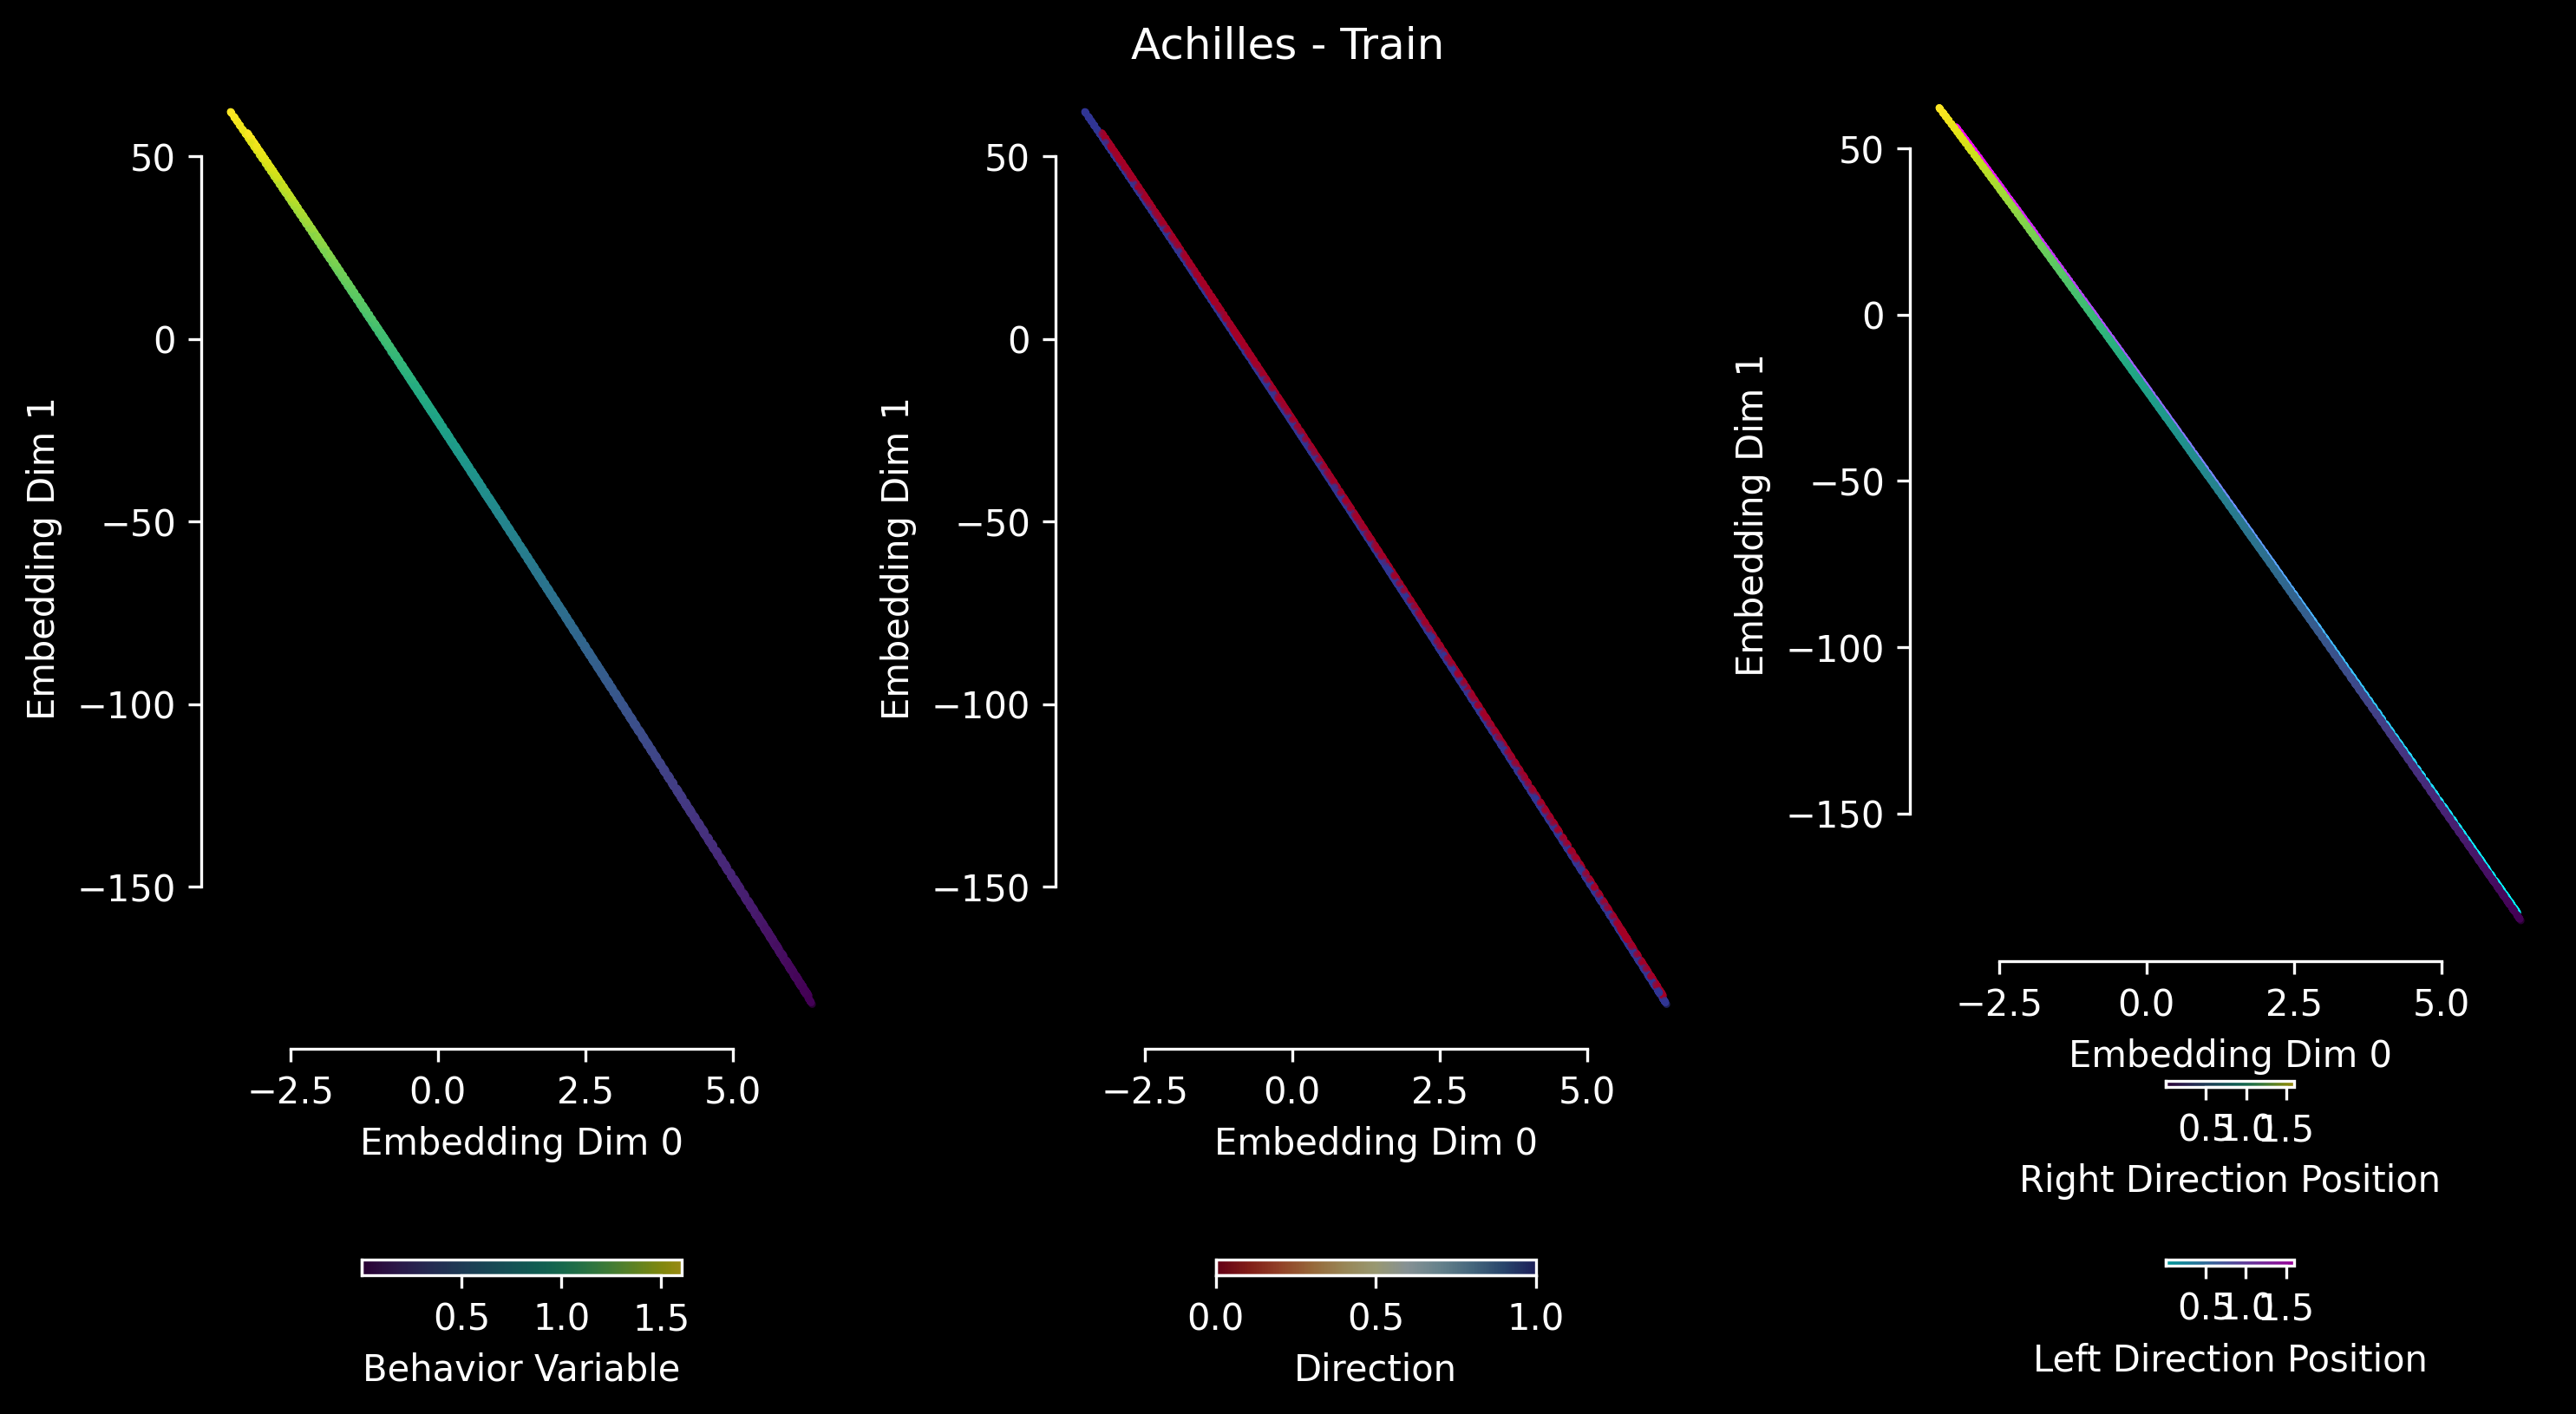

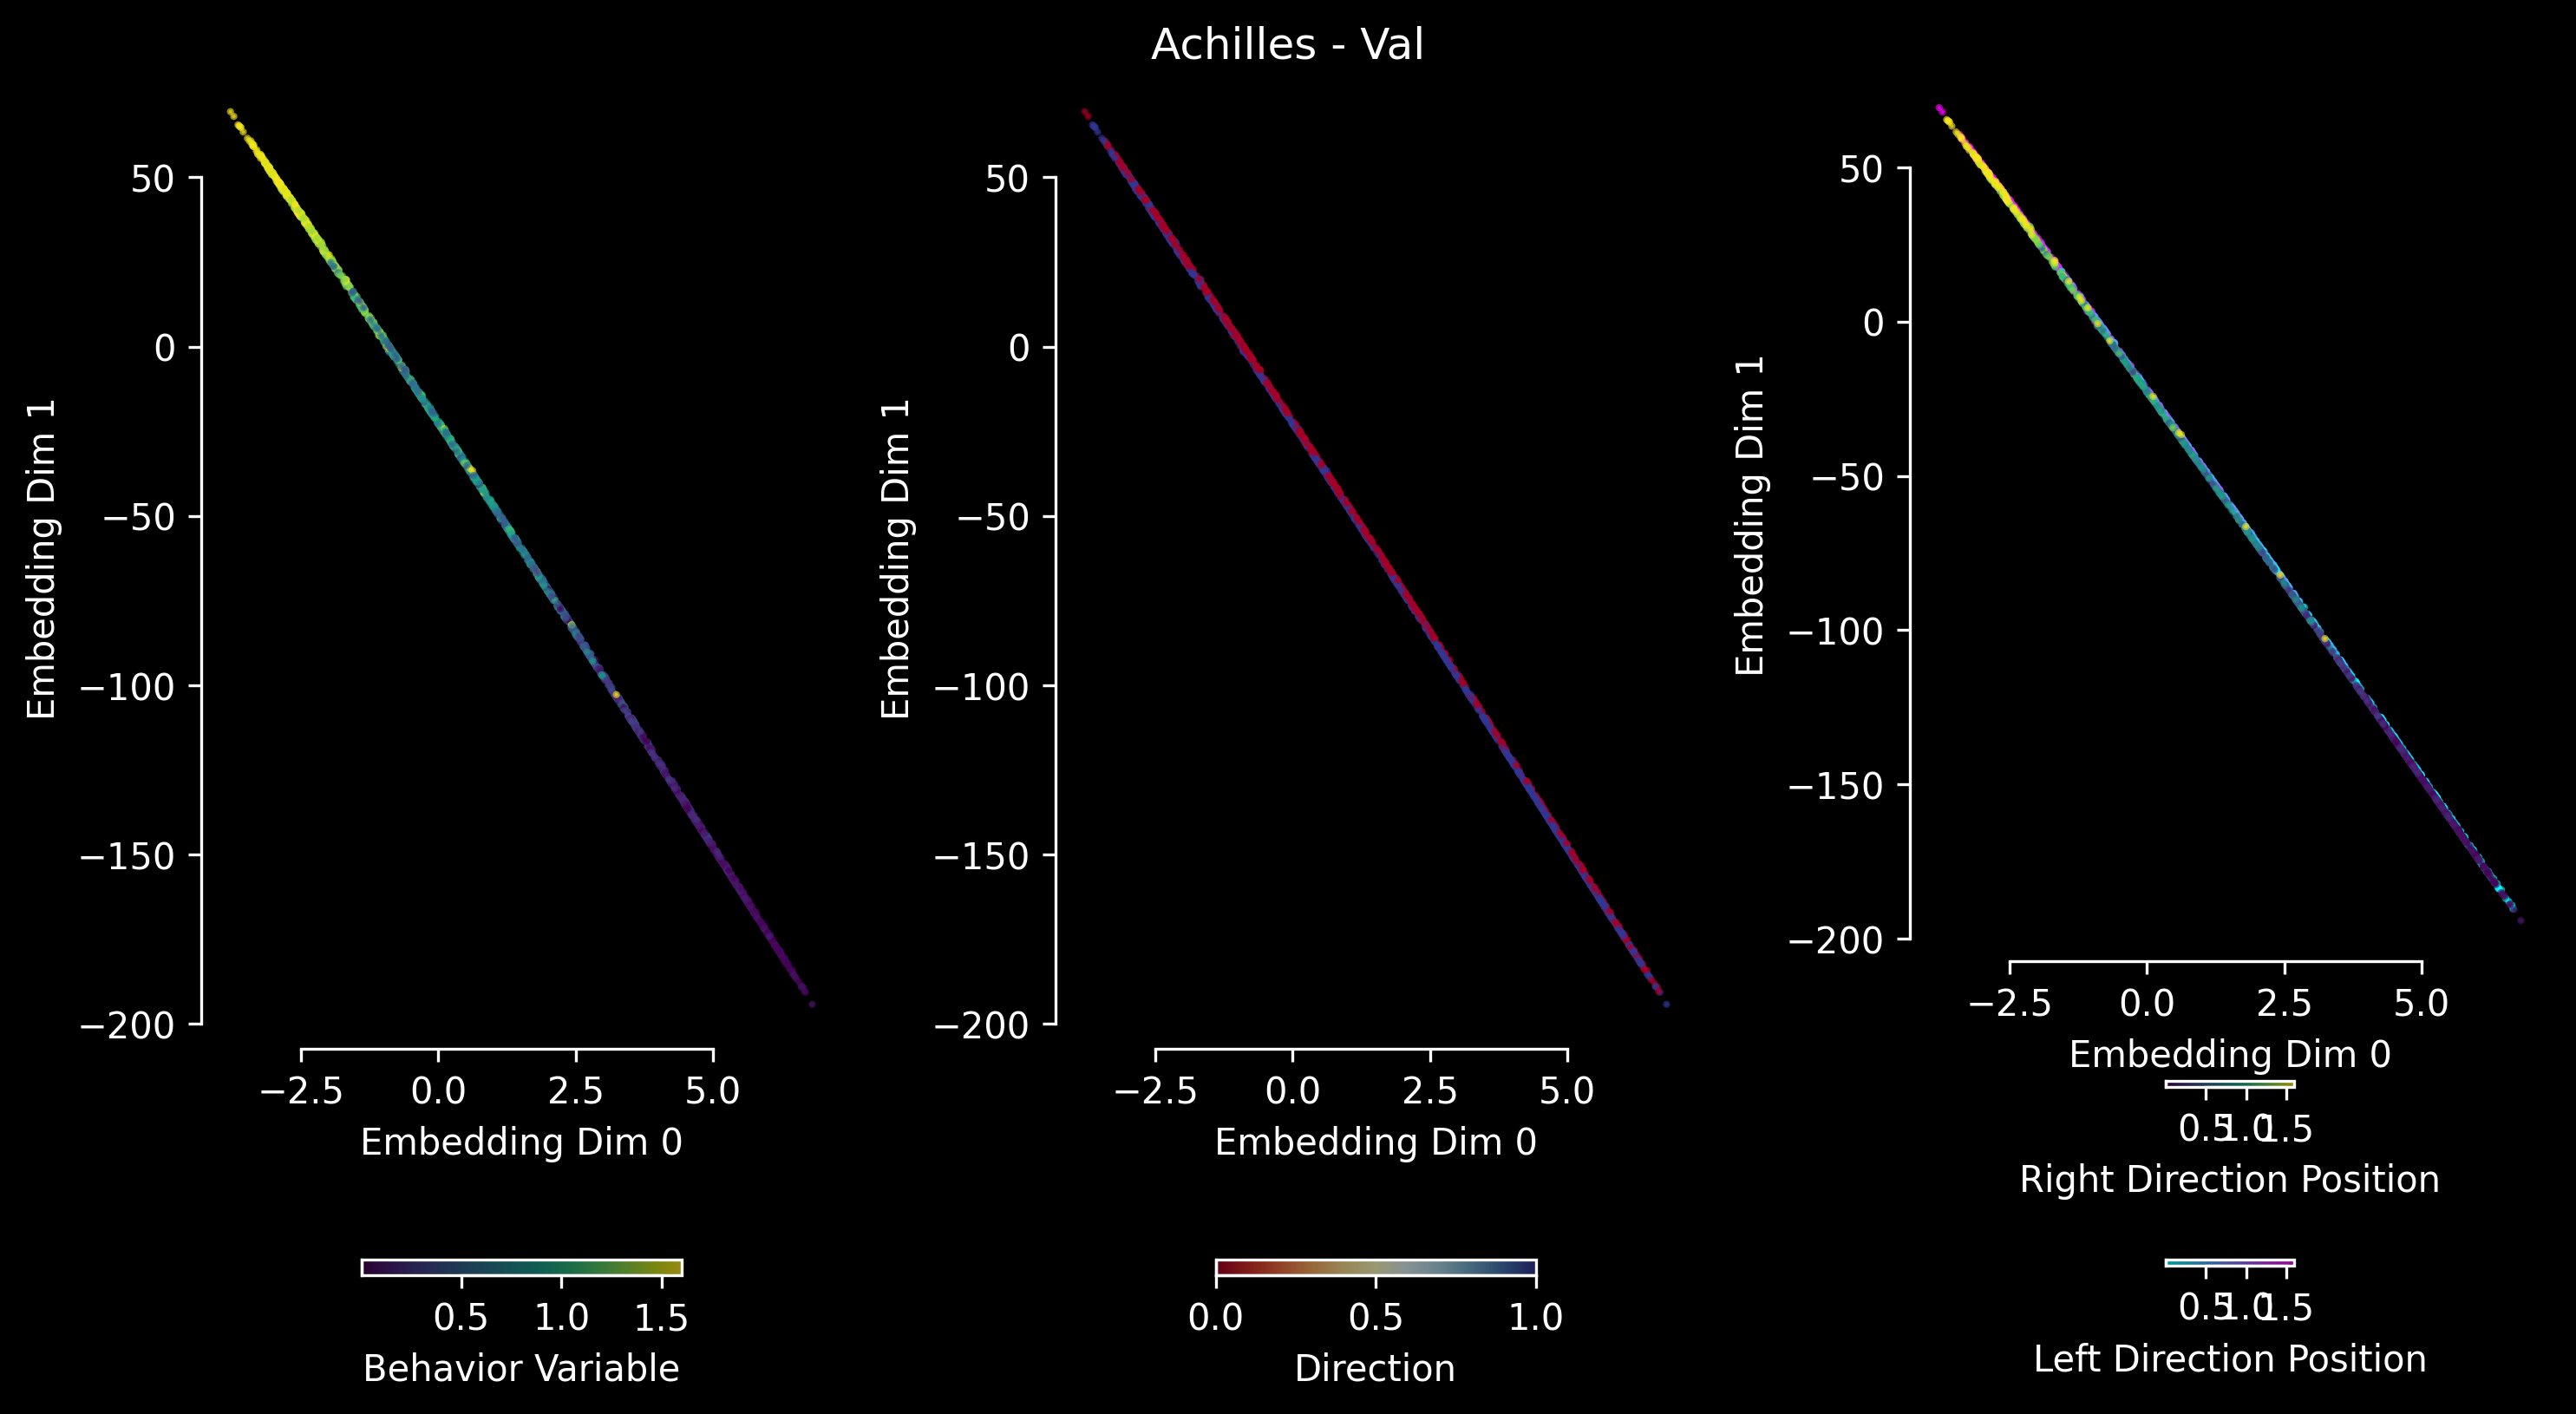

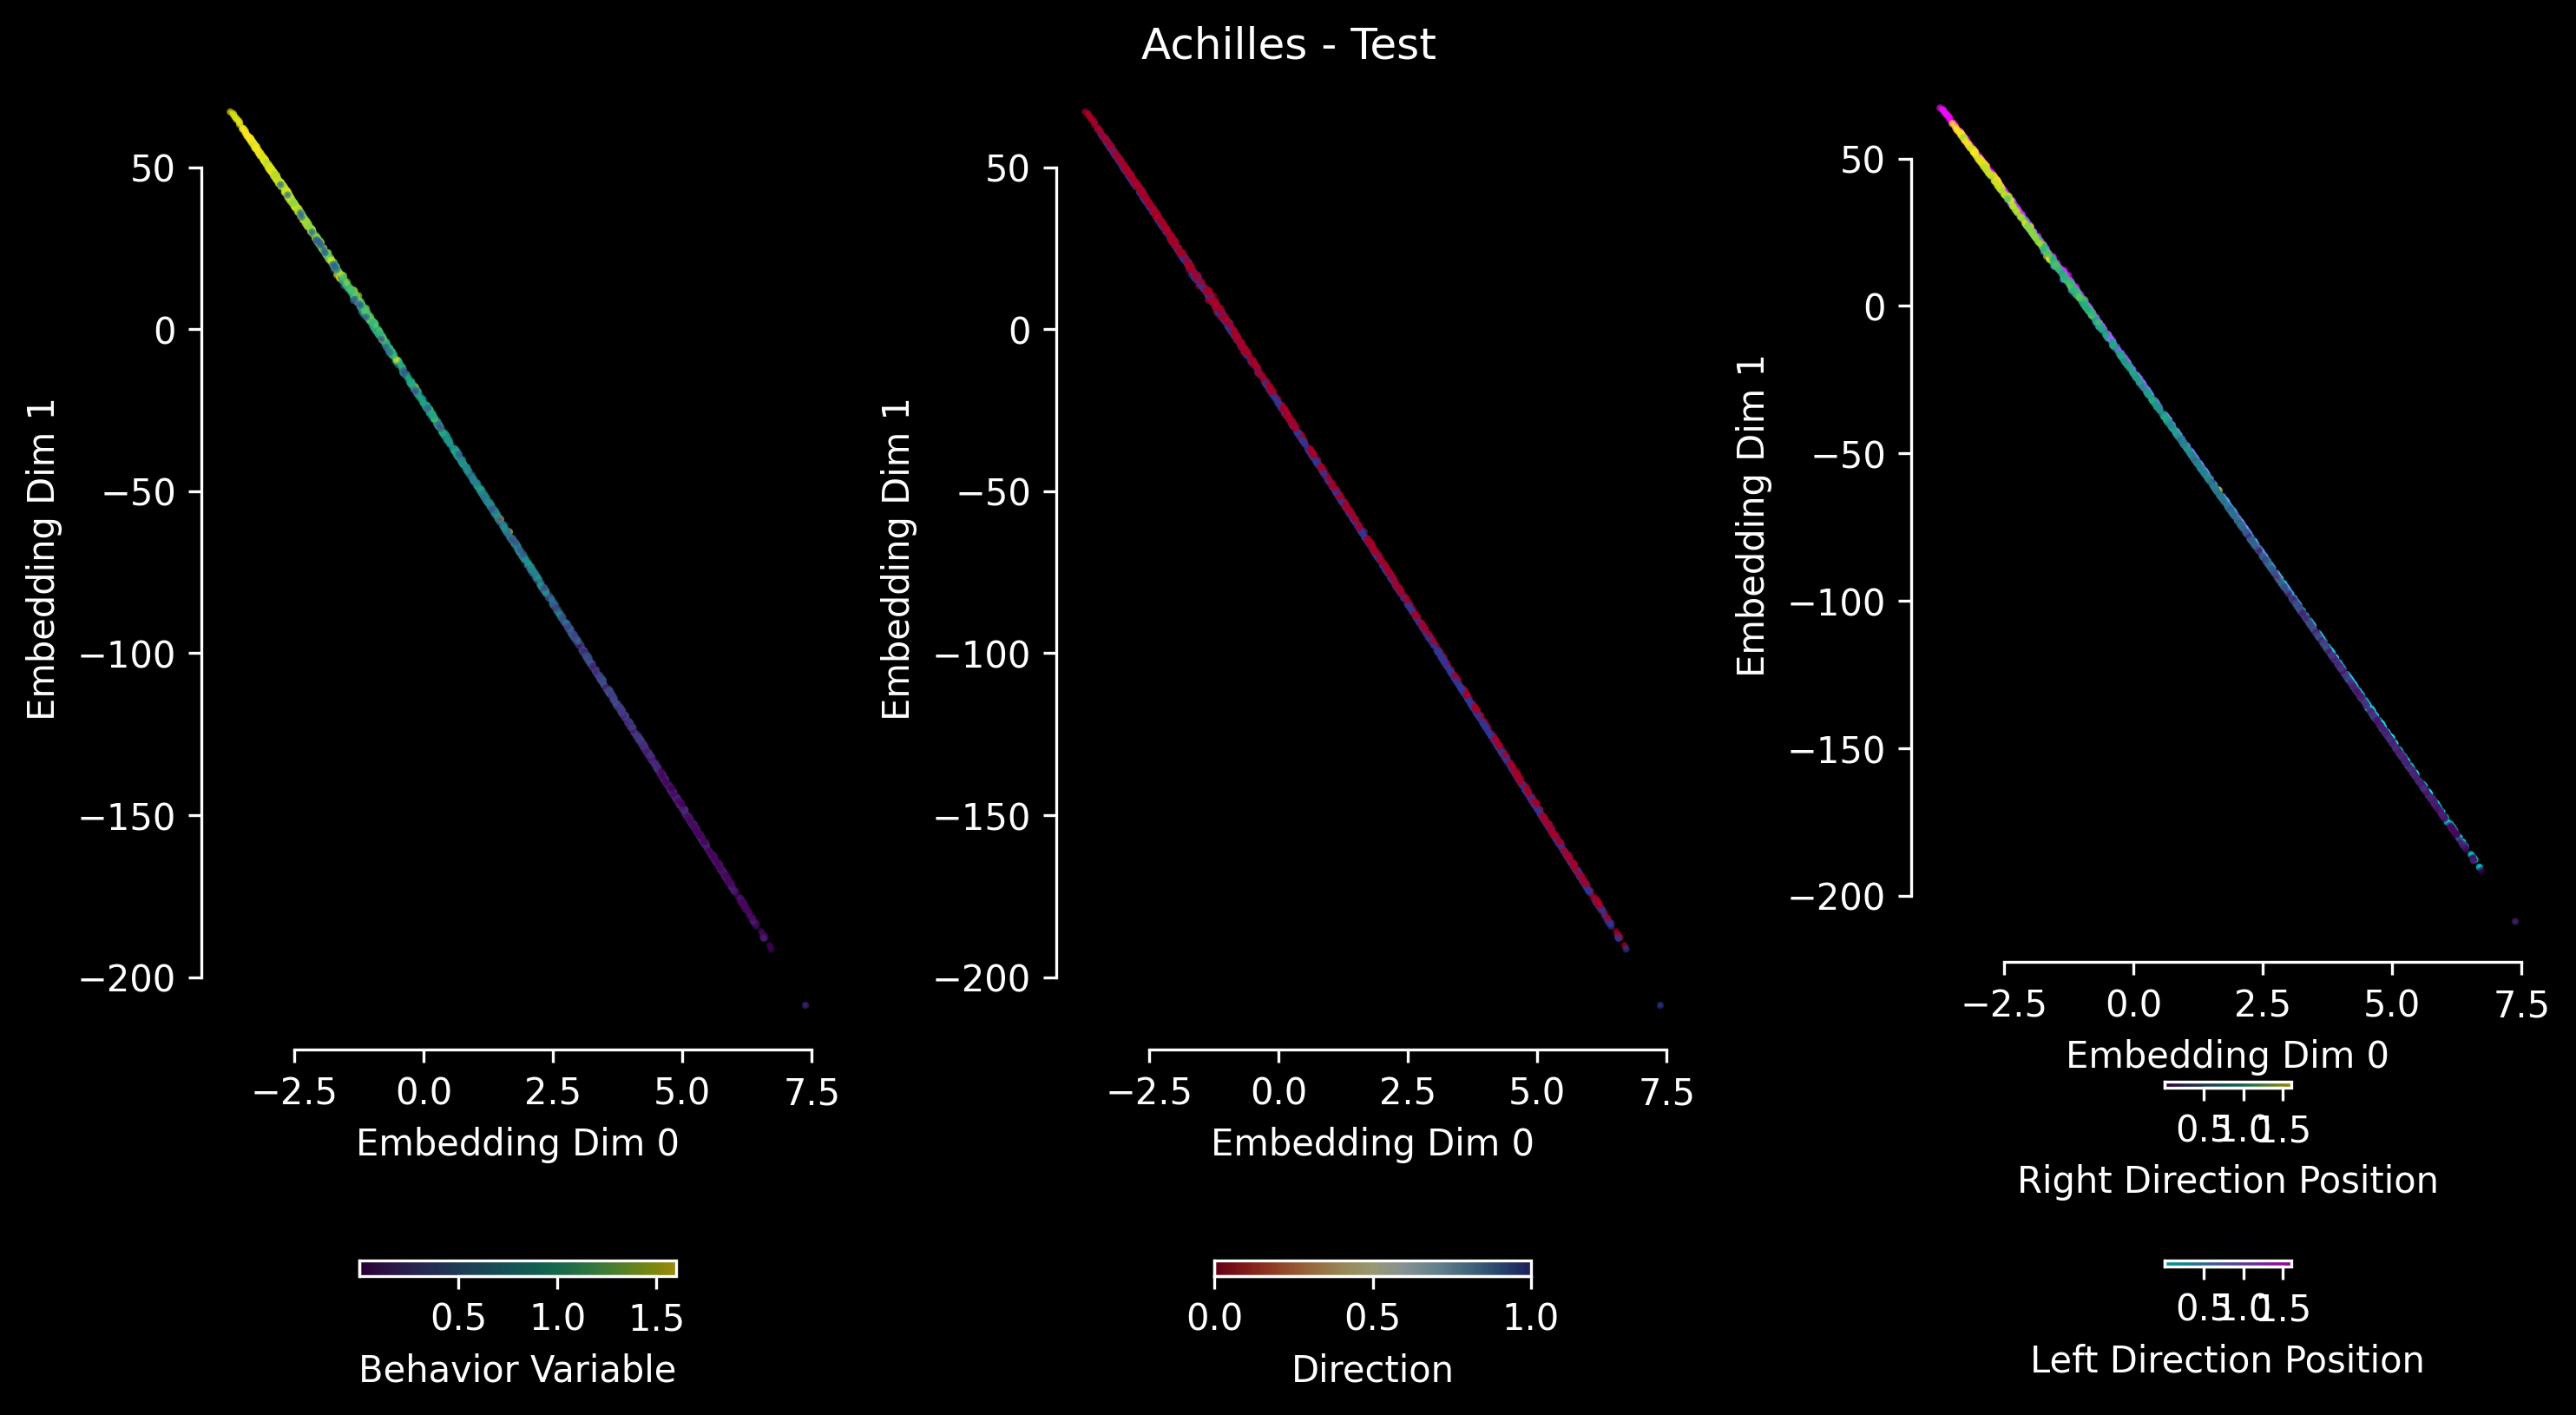

/scratch/slurm_tmpdir/job_1589035/ipykernel_2379787/411513806.py:459: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  bar.set_color(plt.cm.get_cmap(cmap)(norm(color_val)))
/scratch/slurm_tmpdir/job_1589035/ipykernel_2379787/411513806.py:318: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color=plt.cm.get_cmap(cmap)(0.0),  # Use colormap for left direction
/scratch/slurm_tmpdir/job_1589035/ipykernel_2379787/411513806.py:326: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instea

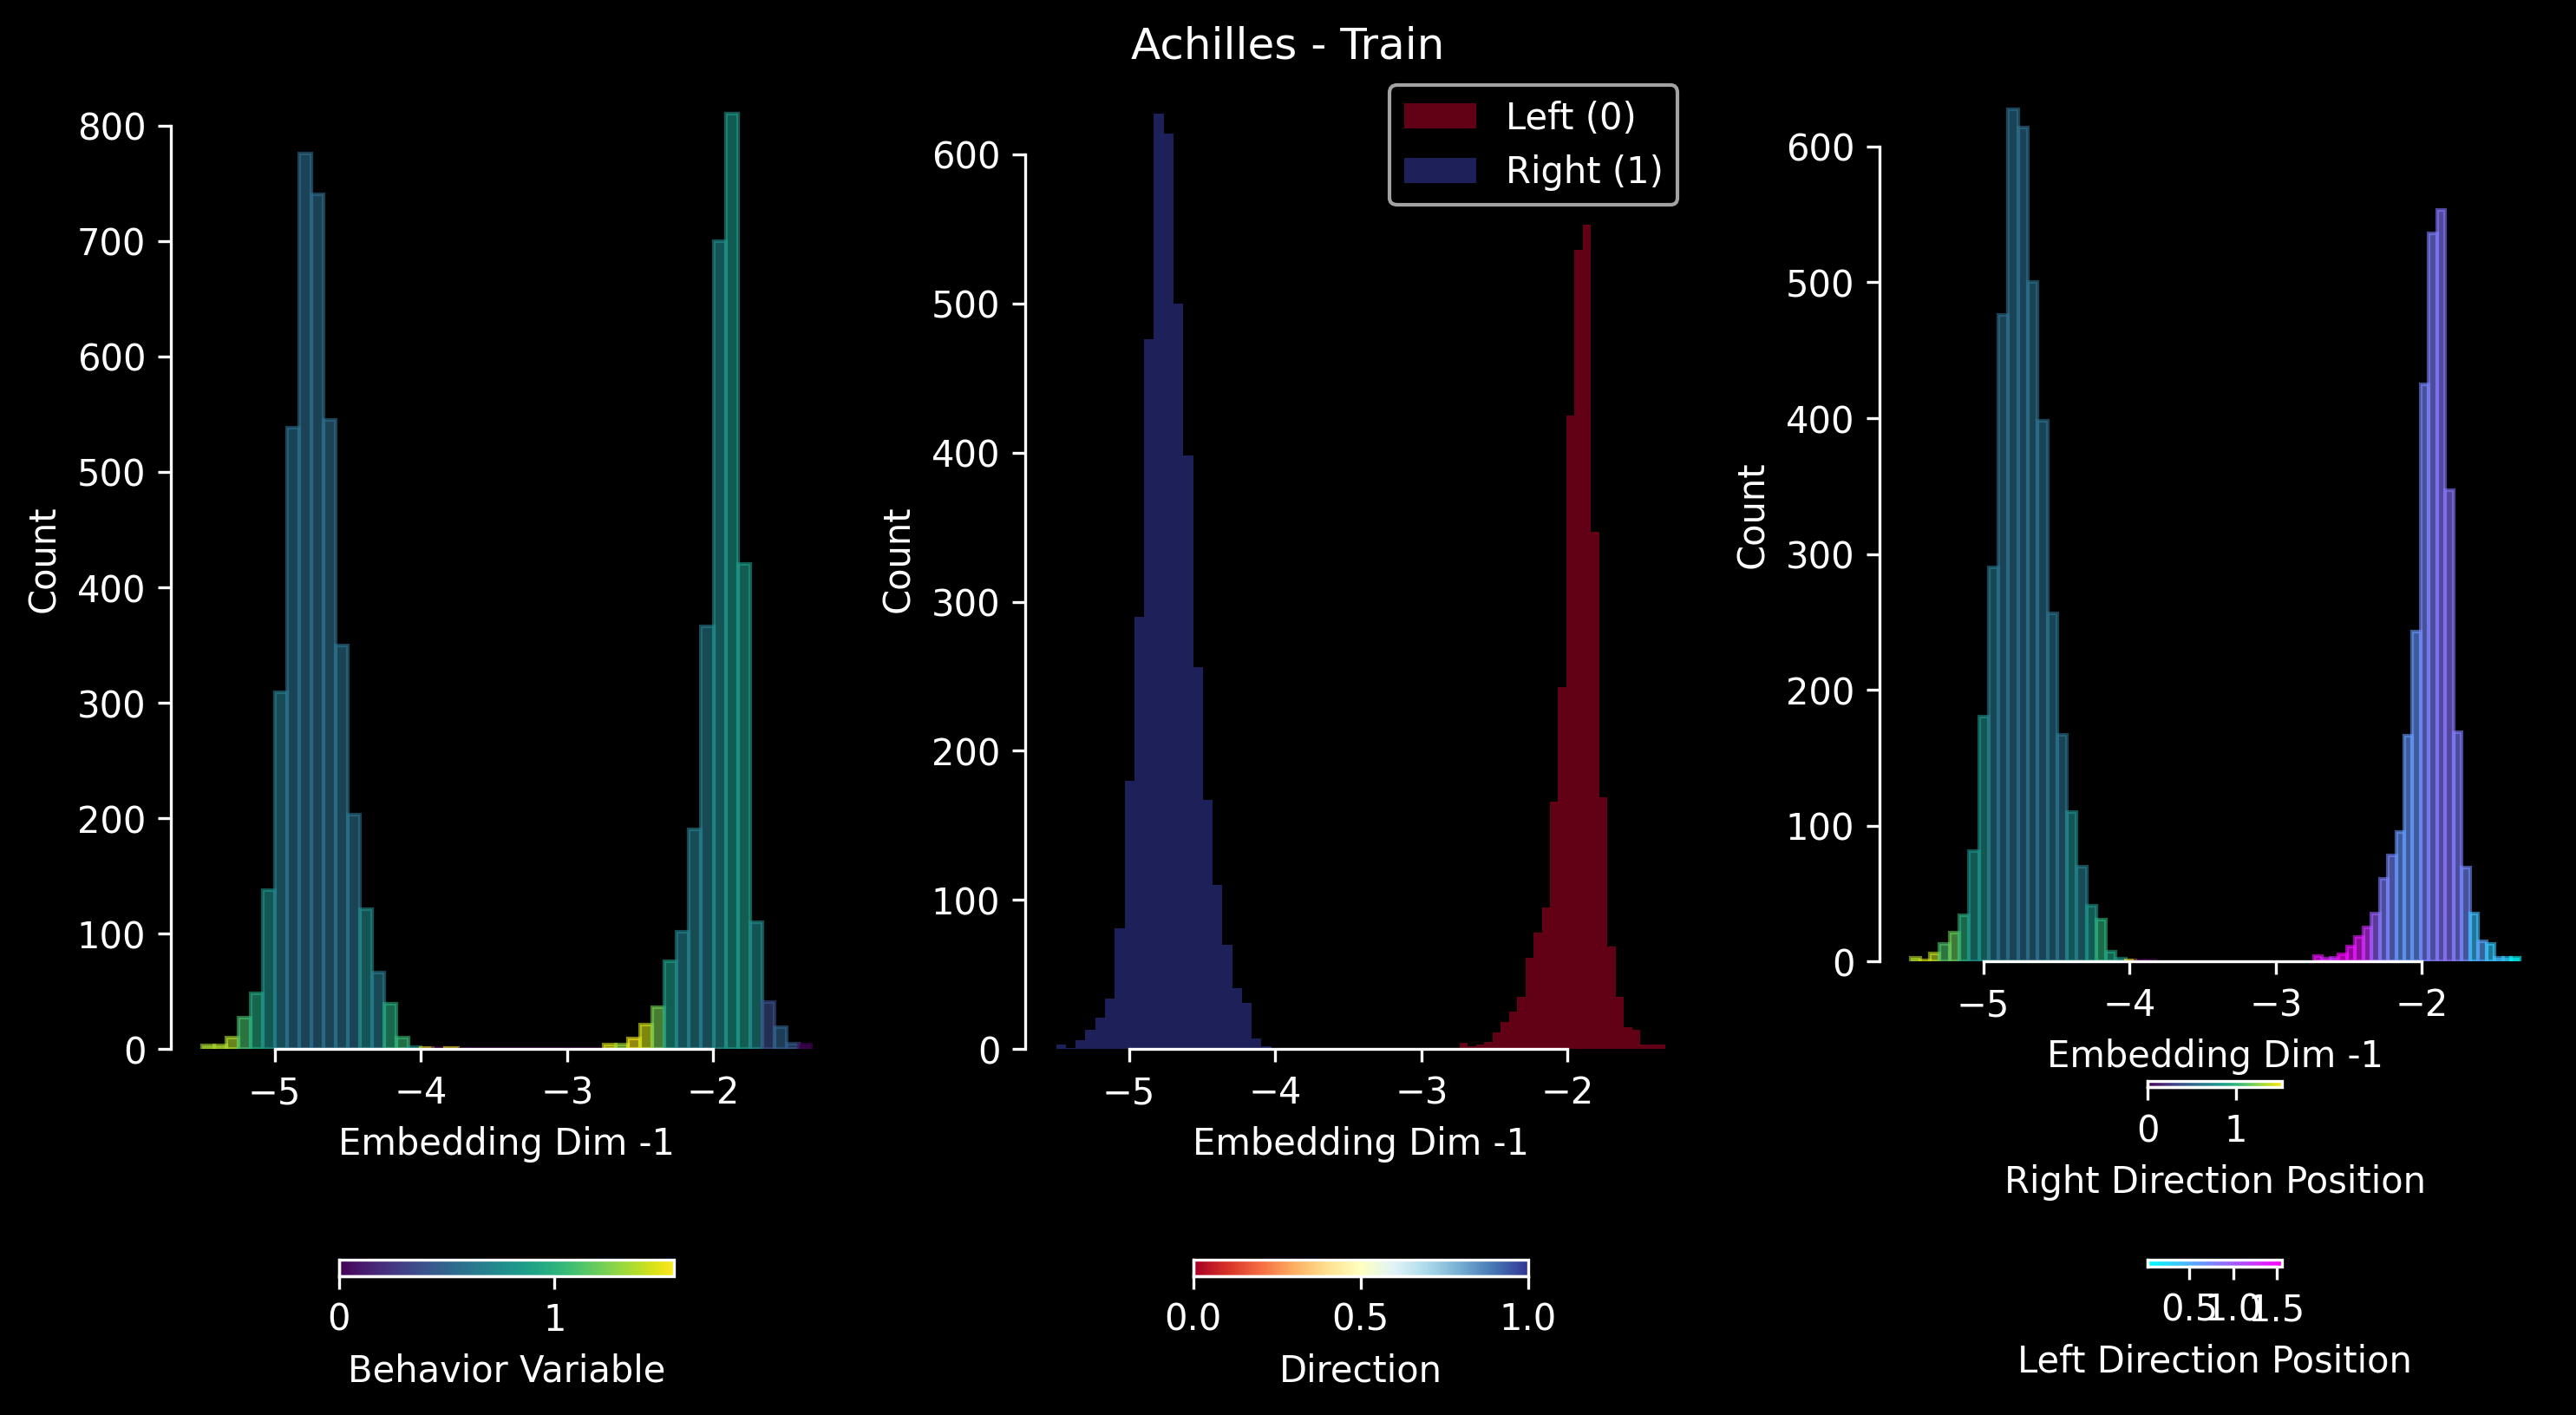

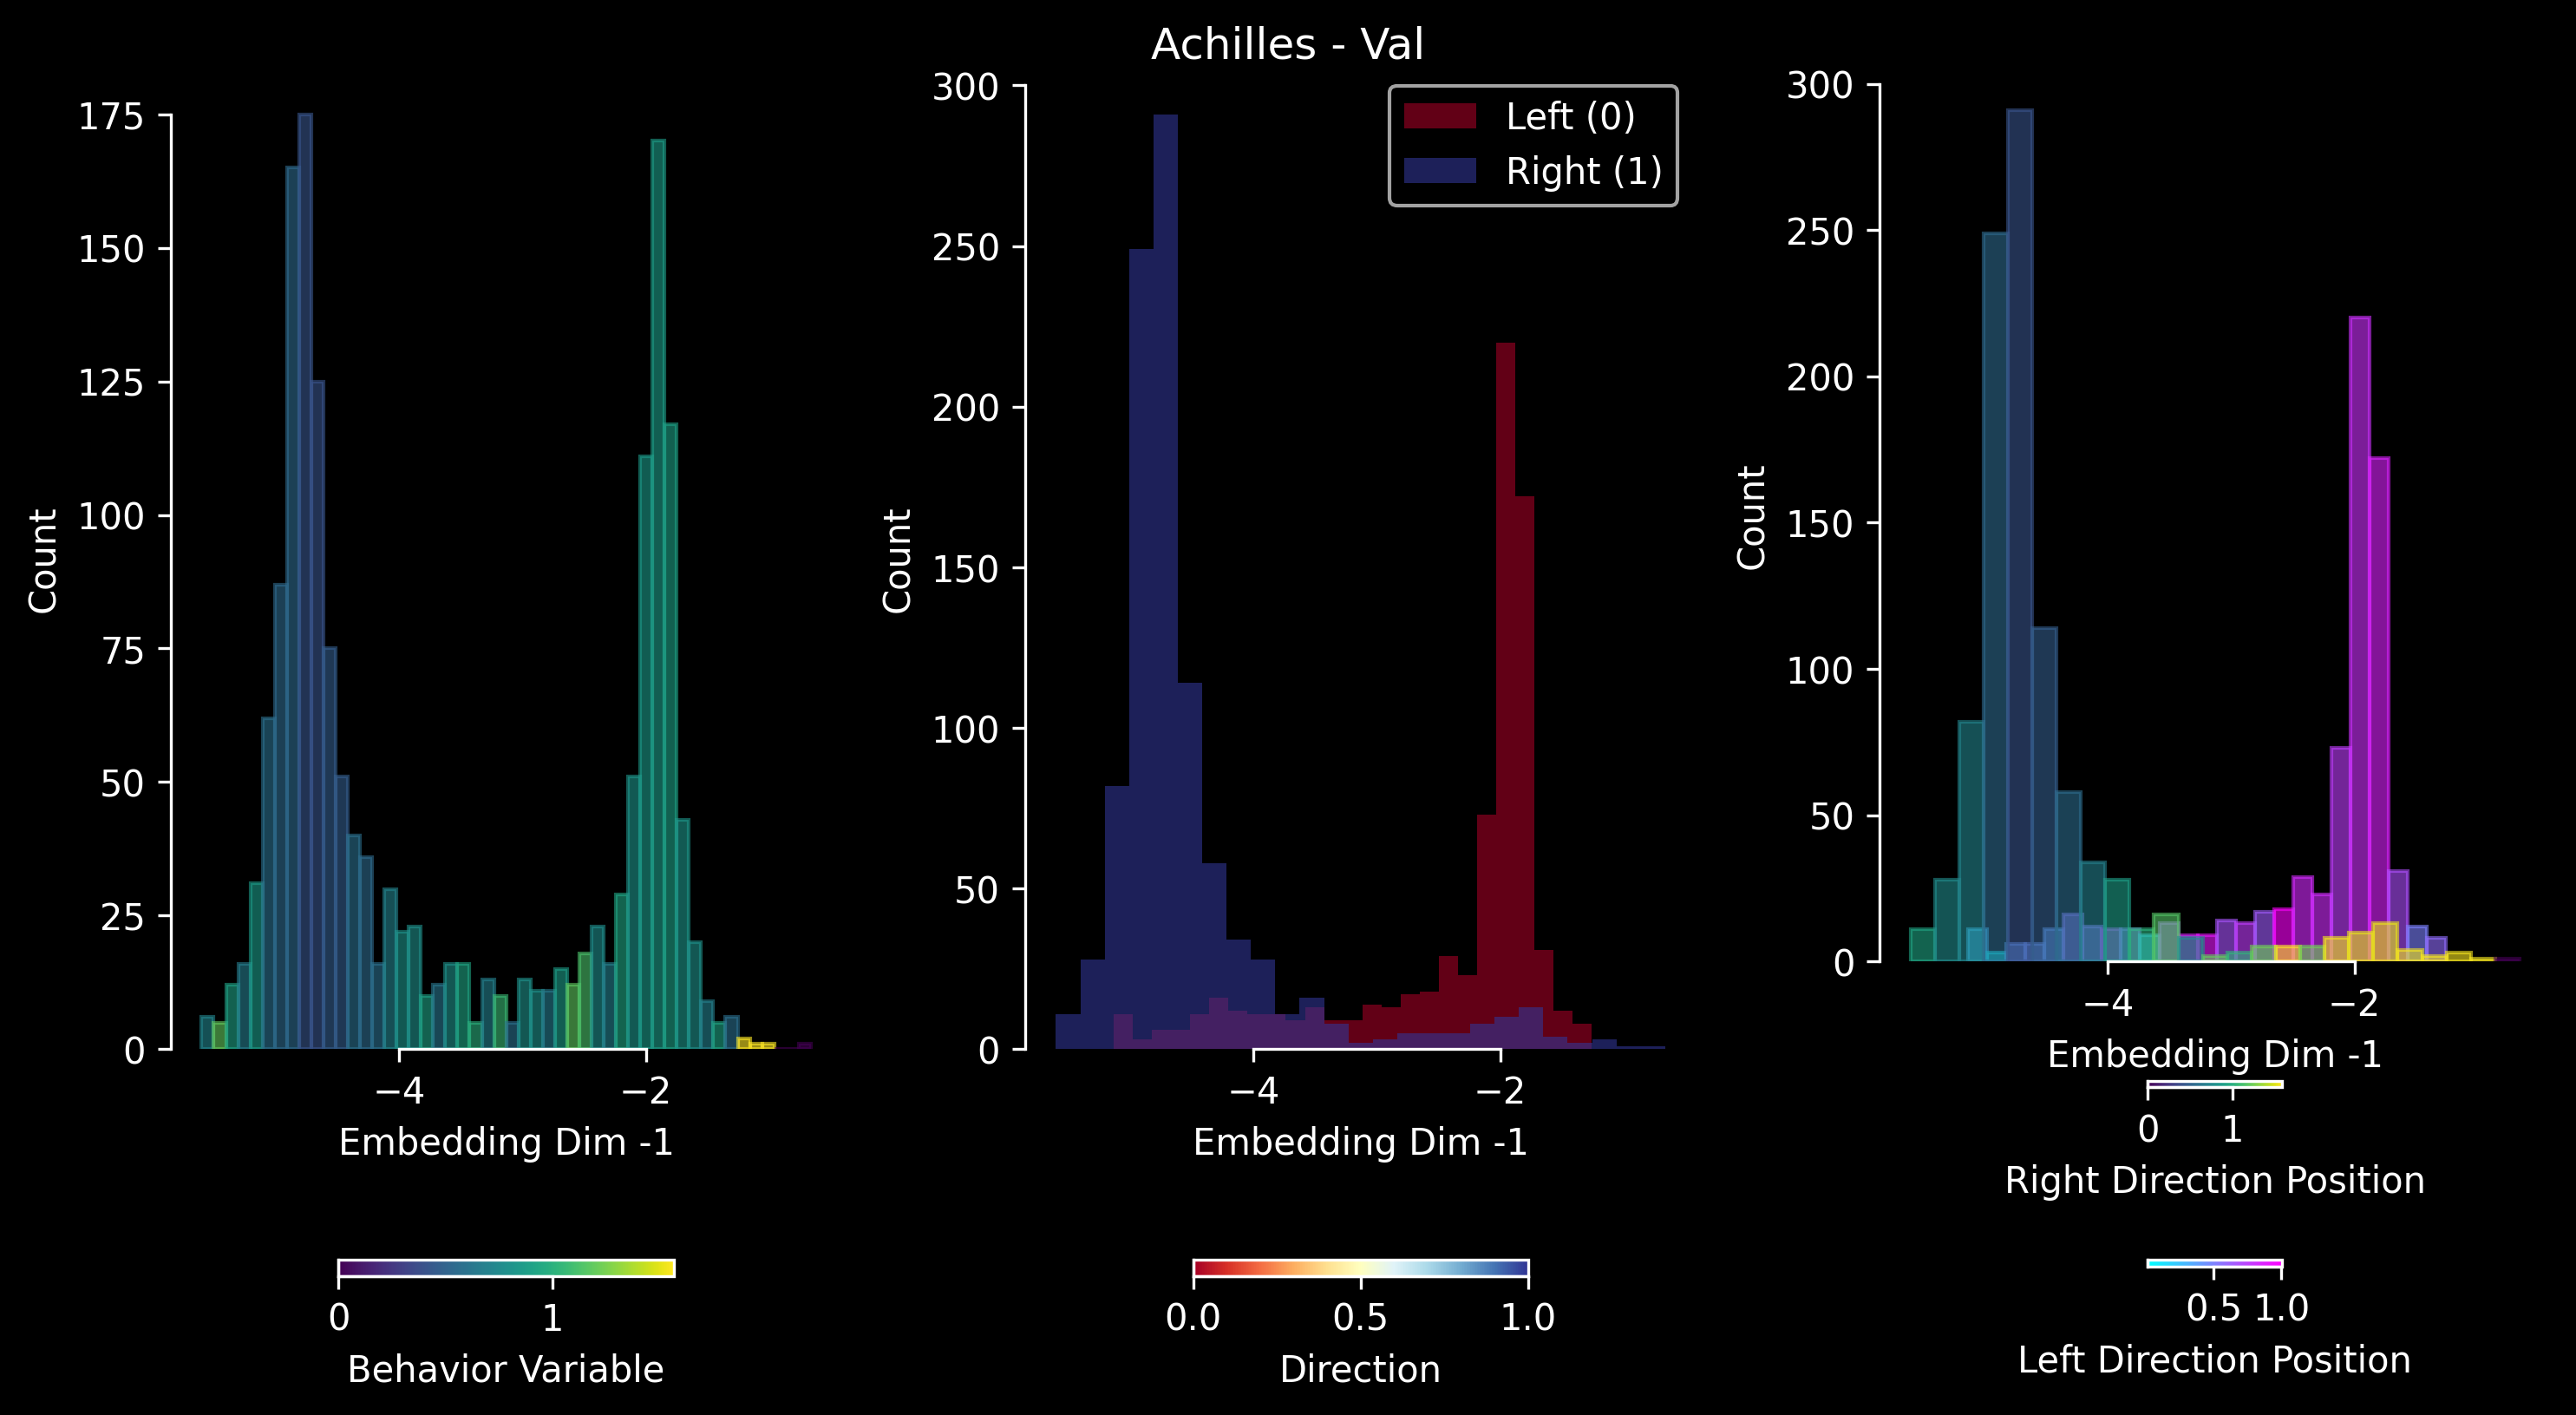

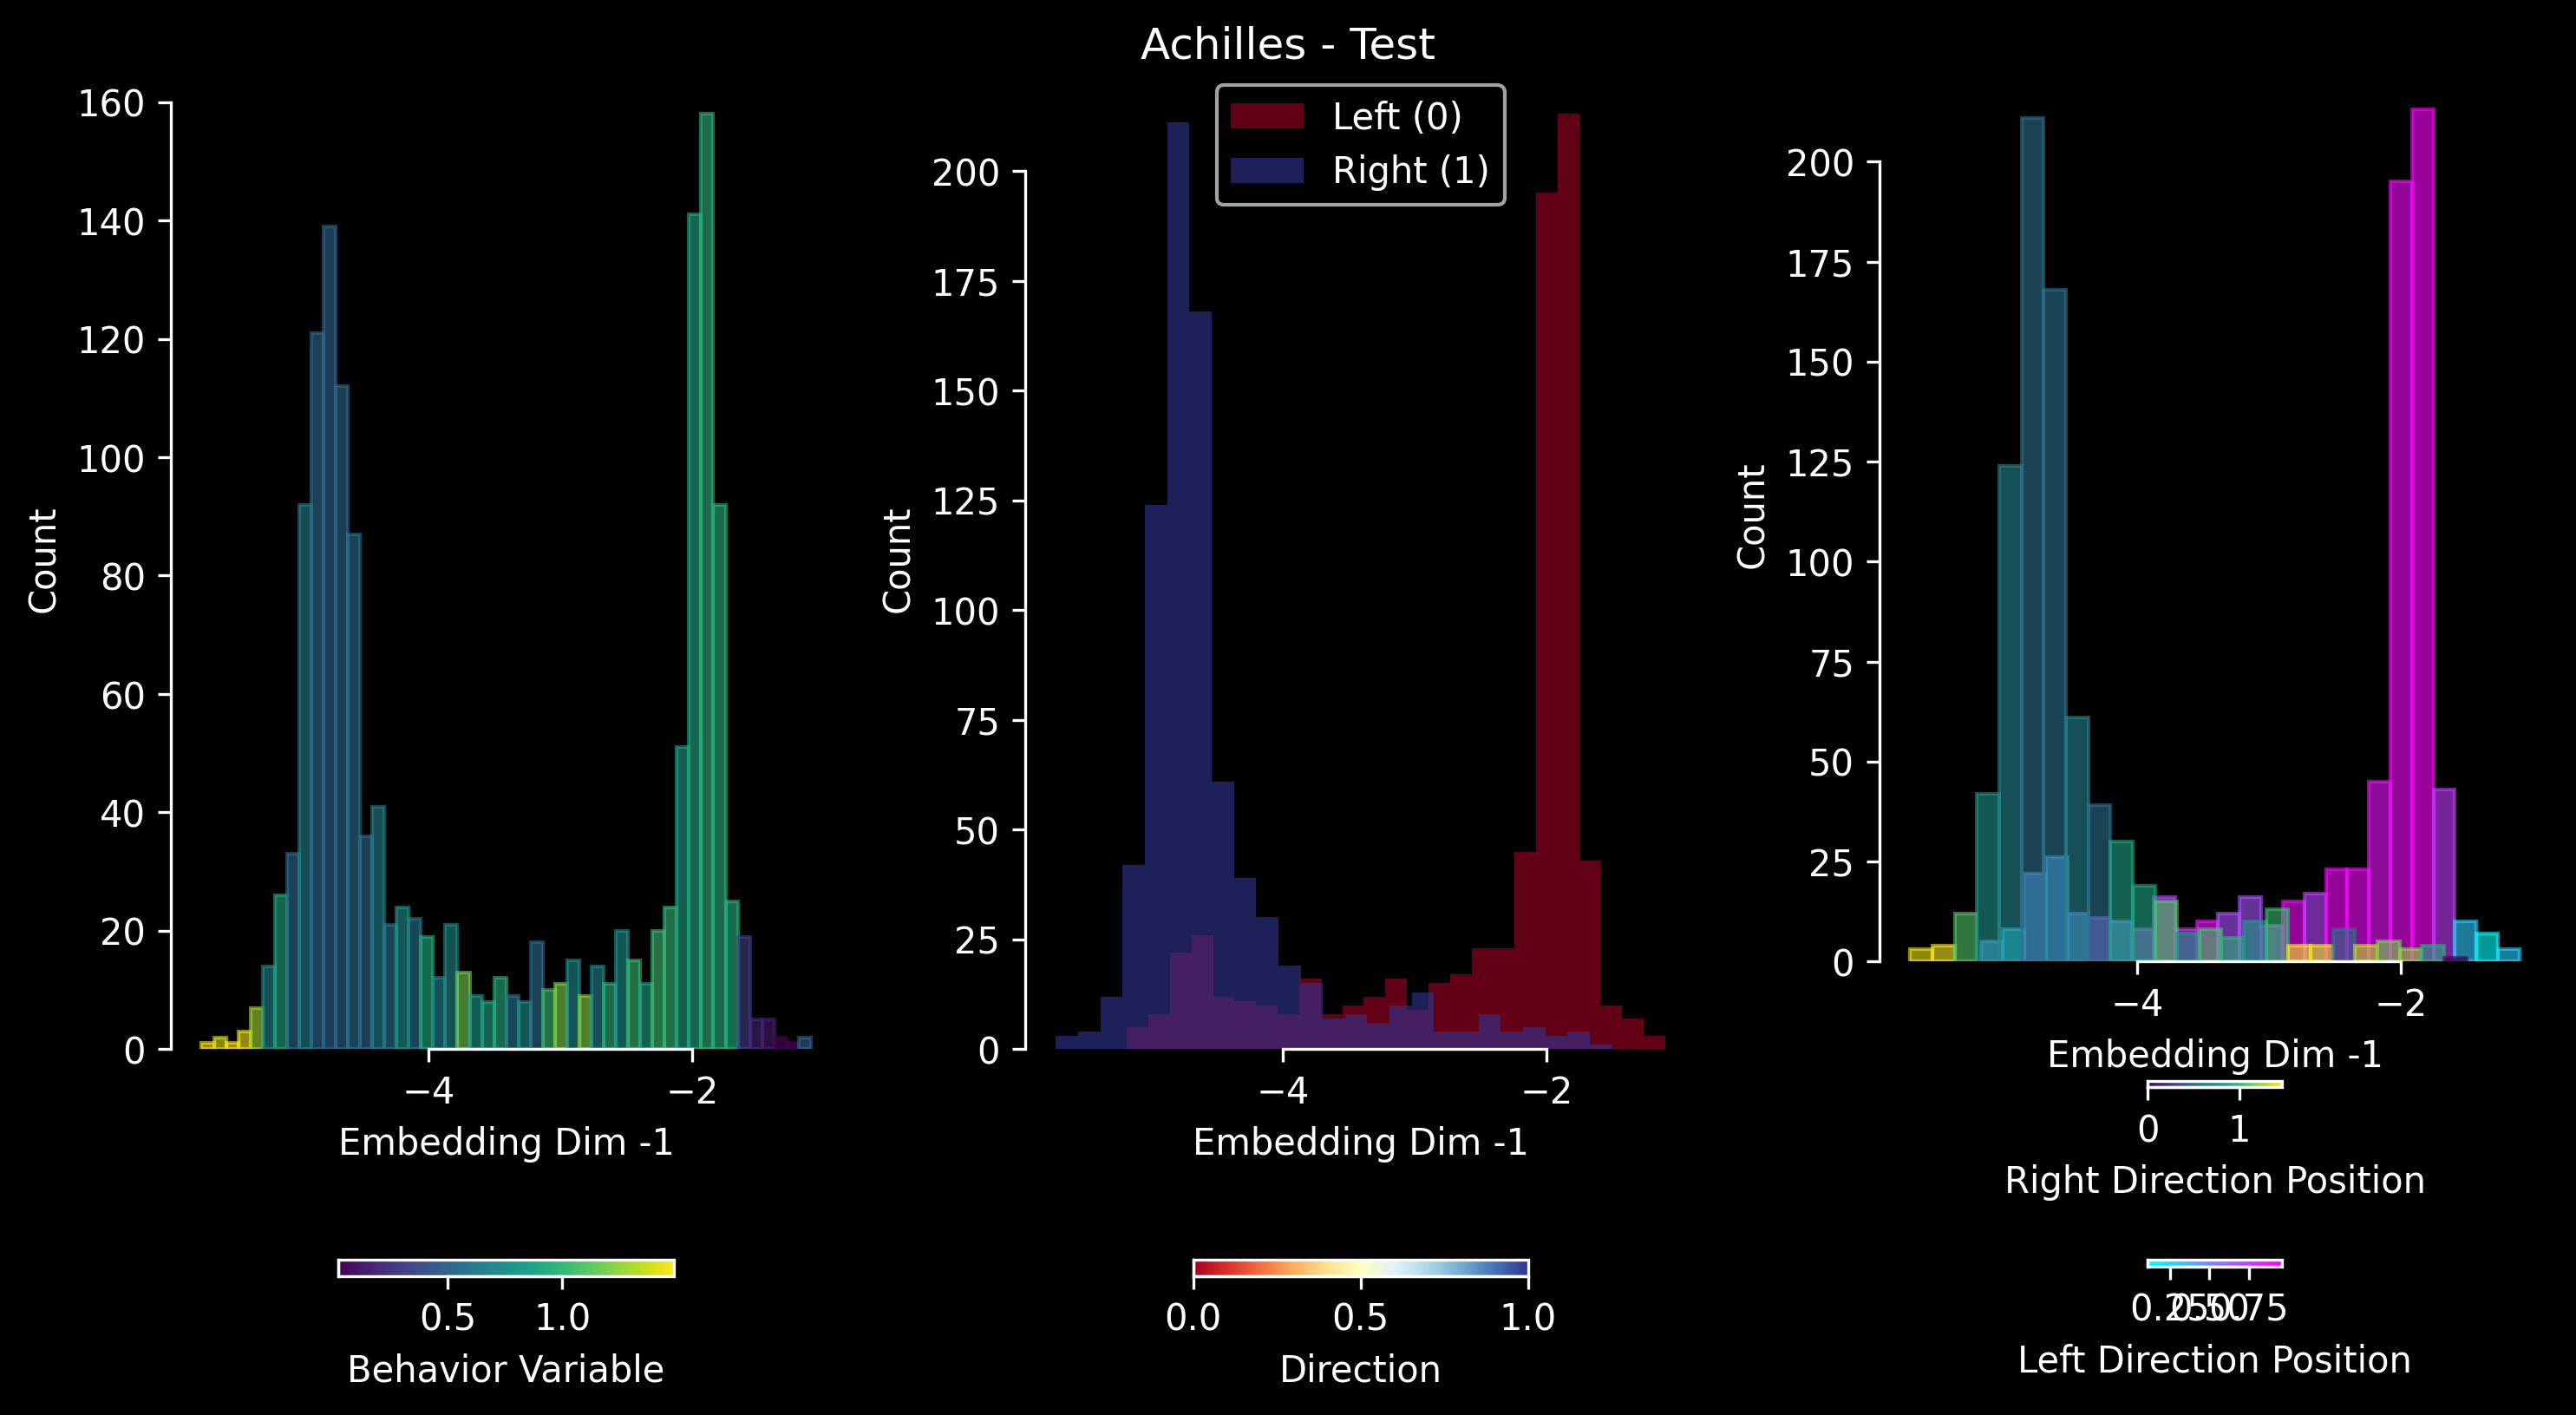

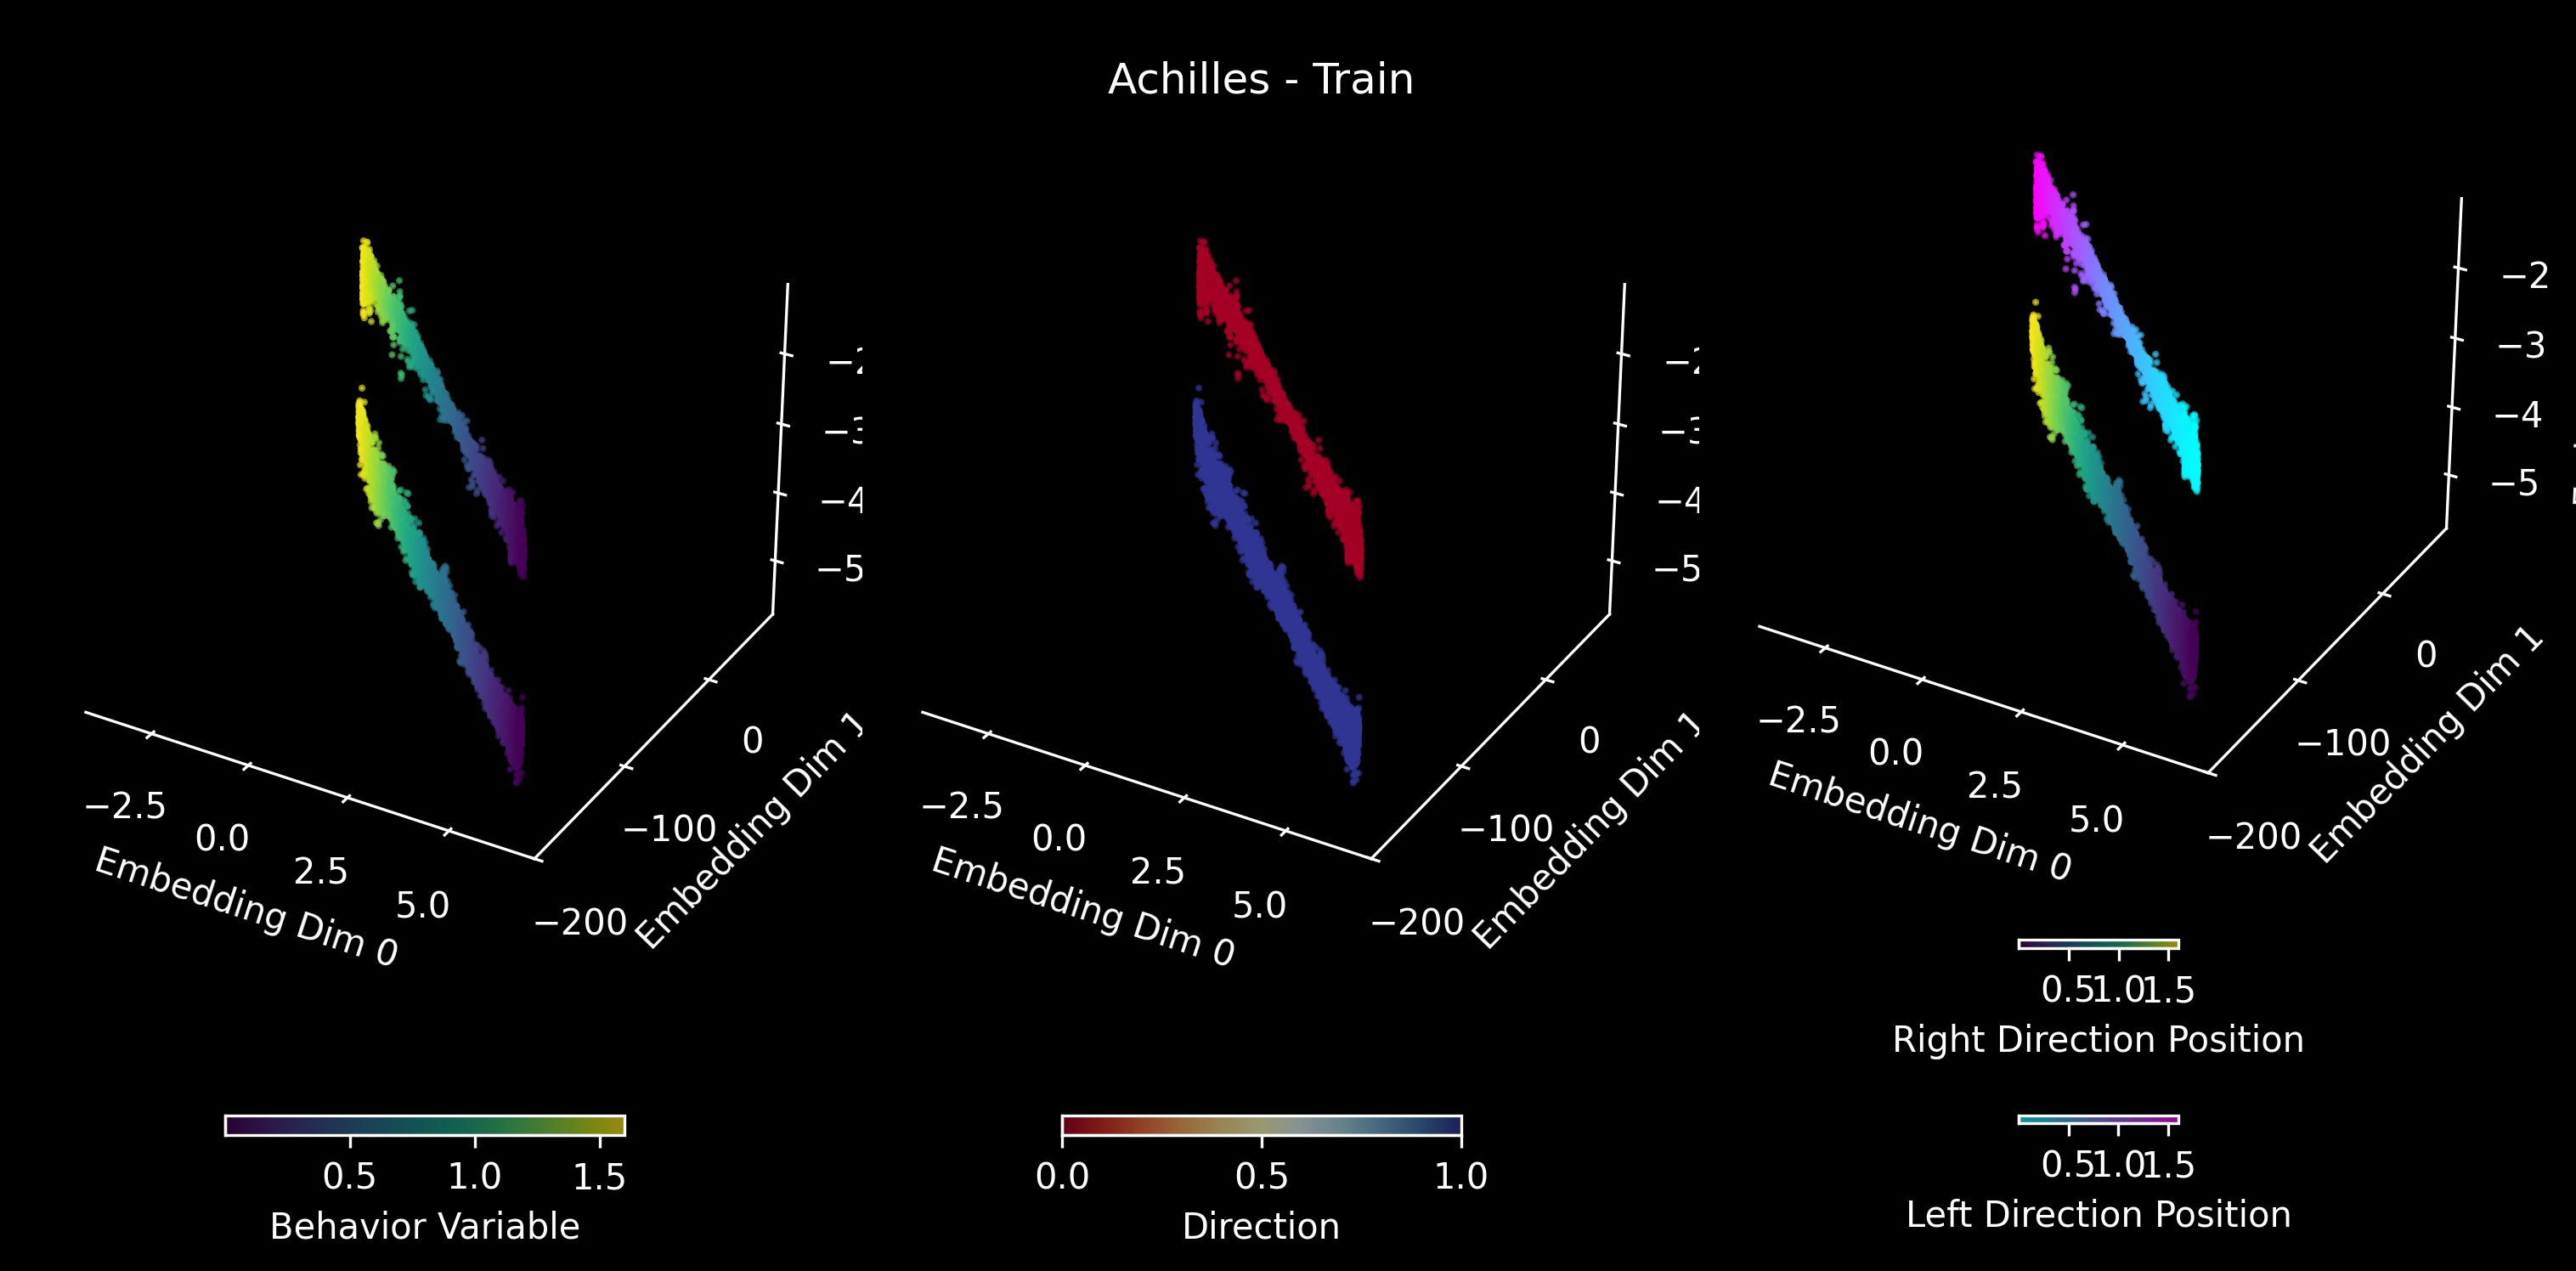

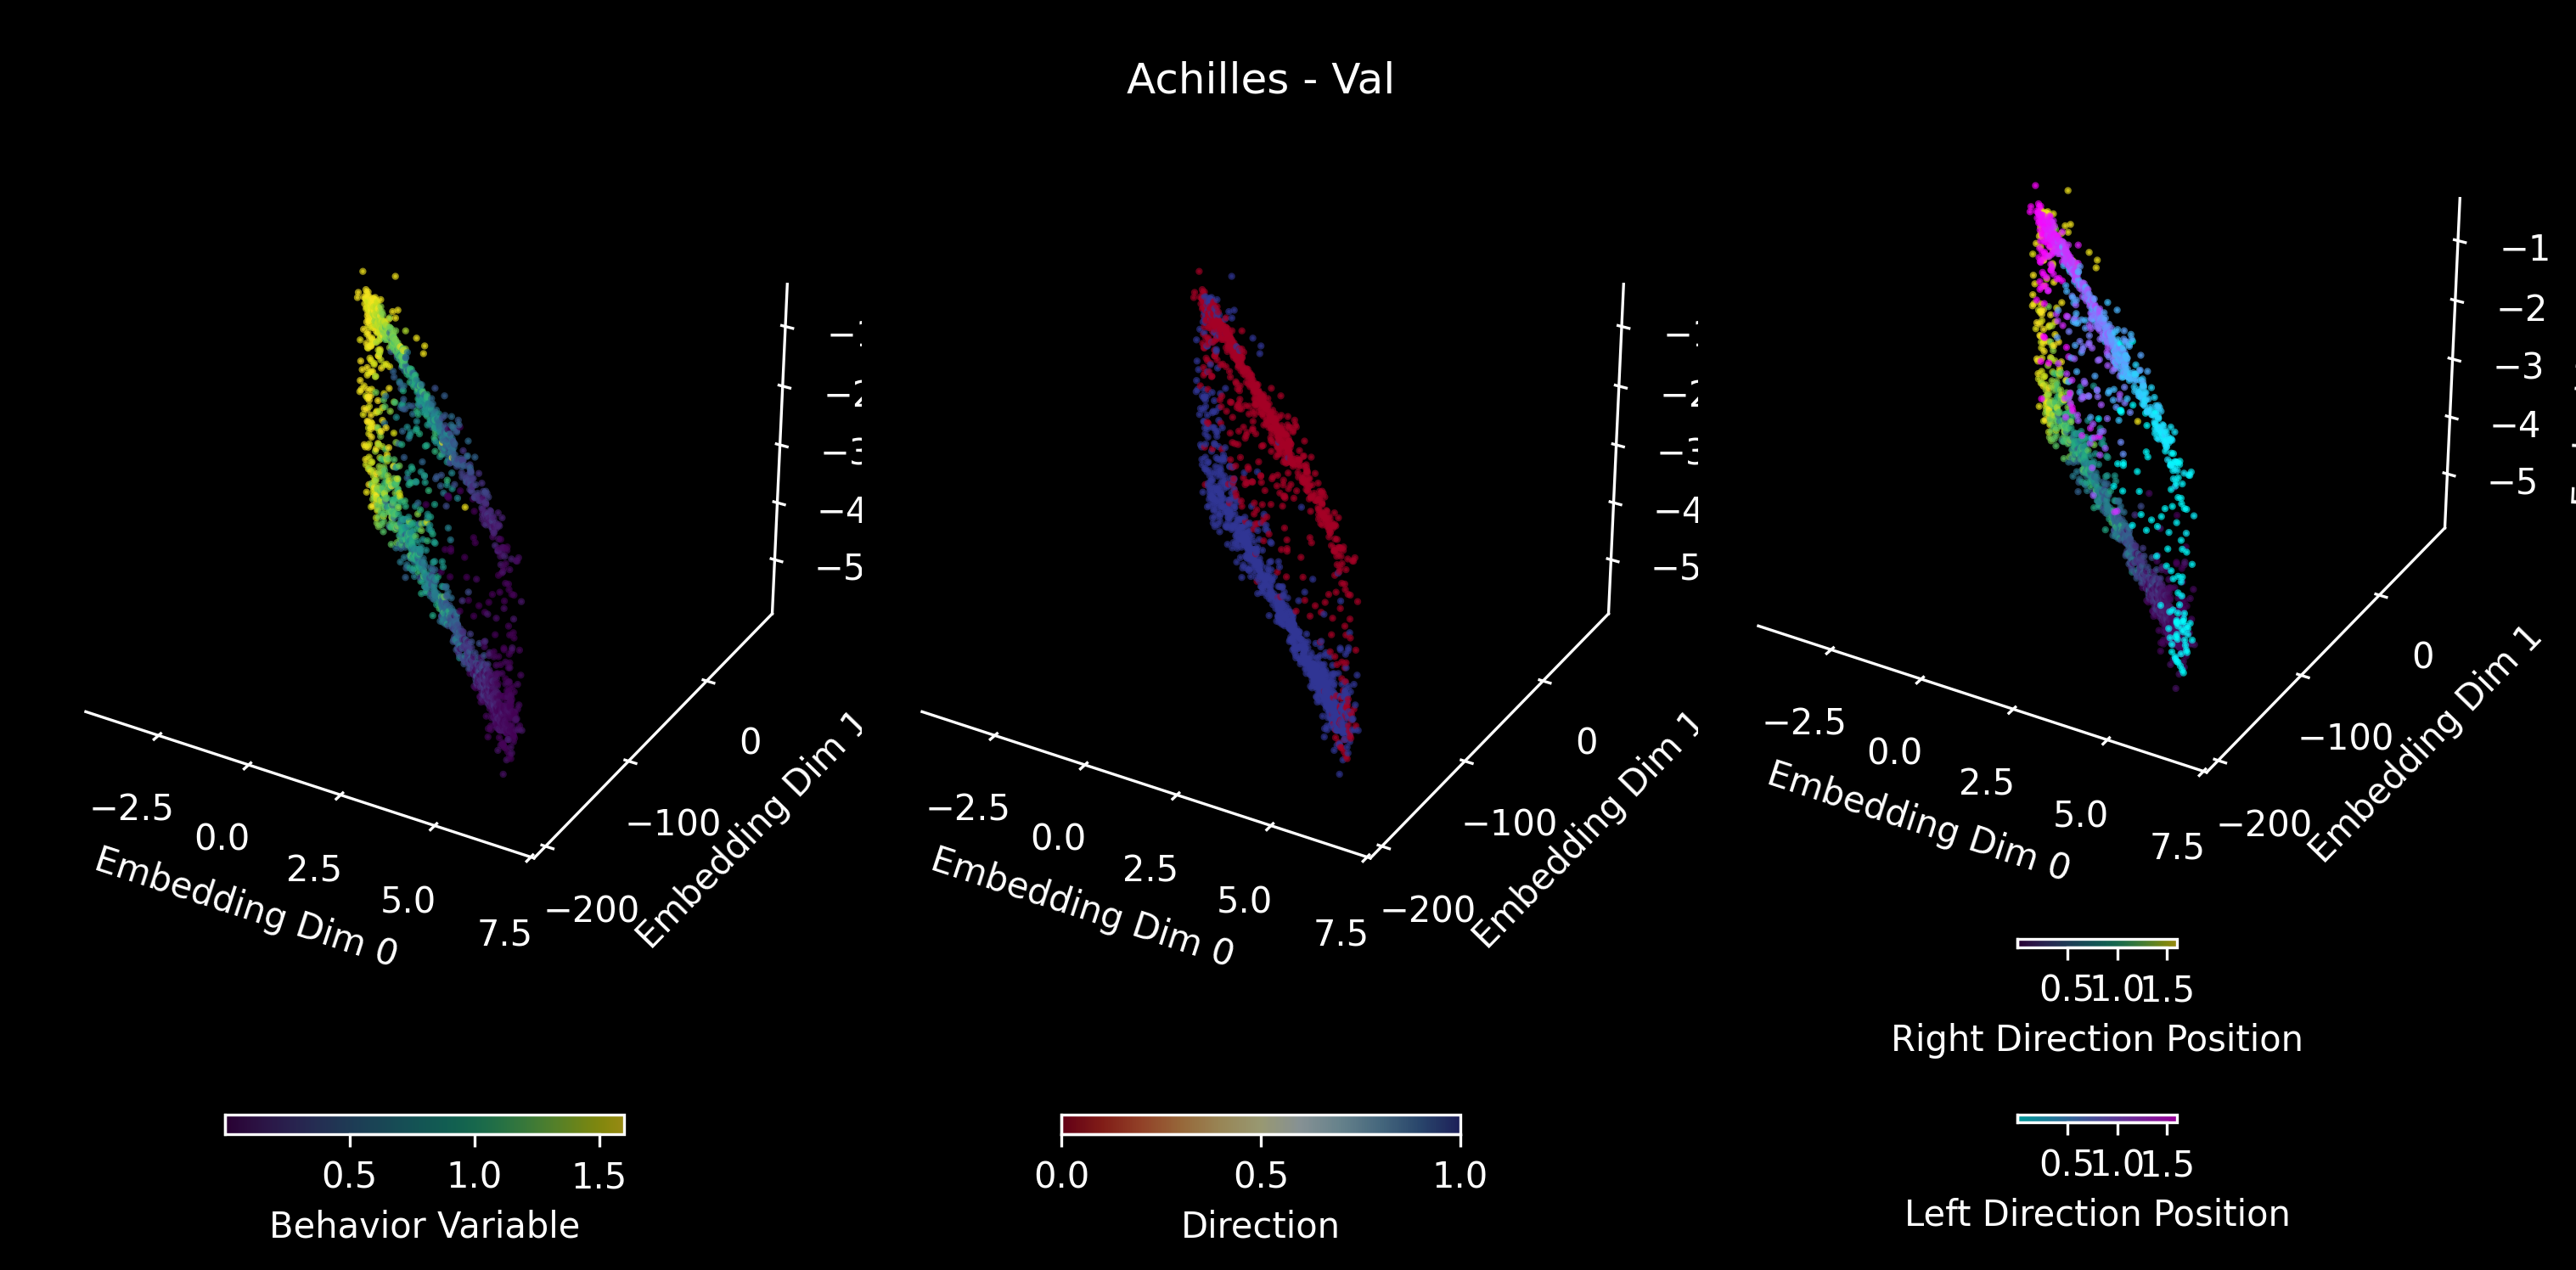

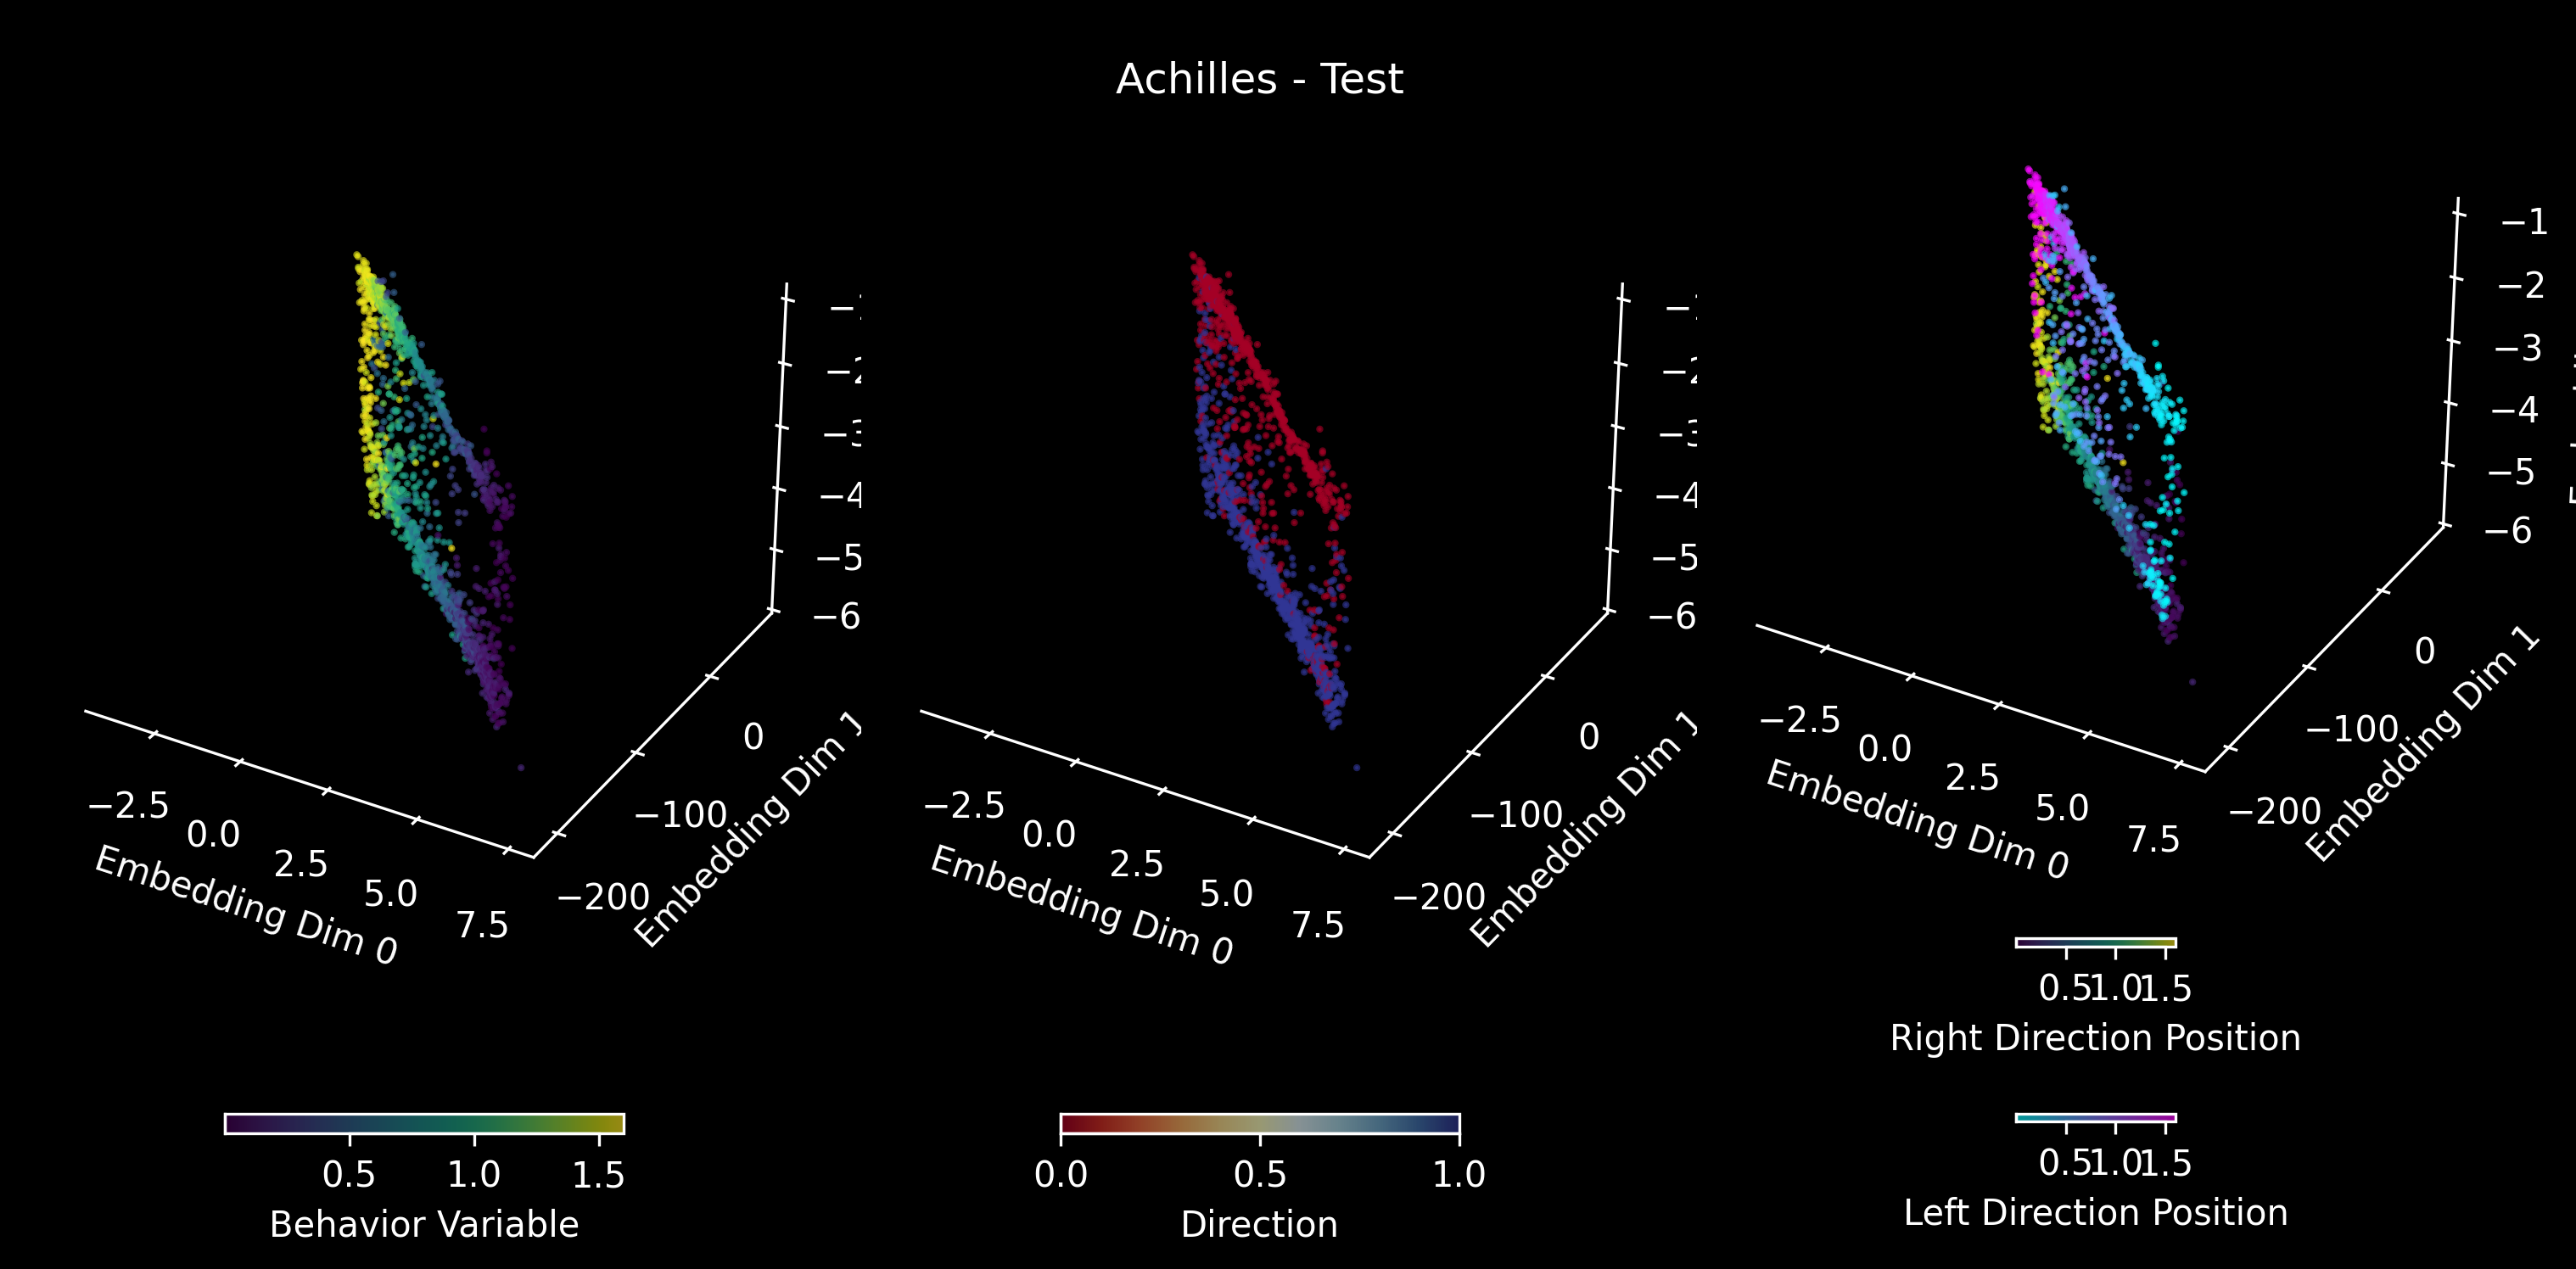

In [17]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
import numpy as np
import seaborn as sns

plt.style.use("dark_background")


def plot_3d_embeddings(
    data,
    emb,
    plt_idx=(0, 1, 2),
    figure_title="",
    title_y=1.0,
    pca=False,
    figsize=(30, 4),
    dpi=300,
    color_by=["position", "direction"],
    cmaps=None,
    alpha=0.6,
    marker_size=1,
    bins=50,
    colorbar_shrink=0.5,
    colorbar_pad=0.02,
    dual_colorbar_shrink=0.4,
    dual_colorbar_pad_left=0.02,
    dual_colorbar_pad_right=0.1,
    show_subplot_title=False,
    show_tick_labels=True,
):
    """
    Plot 3D, 2D, or 1D embeddings colored by behavior, time, direction, and trial ID.

    Args:
        data: Dictionary containing behavioral data
        emb: Embeddings tensor or array
        plt_idx: Tuple of 1, 2, or 3 dimension indices to plot
        figure_title: String to use as the figure title
        pca: If True, run PCA on the selected dimensions before plotting
        figsize: Figure size tuple
        dpi: Figure DPI
        color_by: List of strings specifying what to color by for each subplot.
                 Options: "position", "direction", "time", "trial_id", "position_direction"
        cmaps: Dictionary mapping color_by options to colormap names. If None, uses defaults.
               For position_direction, should contain 'left' and 'right' keys.
        alpha: Transparency value for scatter plots (0-1)
        marker_size: Size of markers in scatter plots
        bins: Number of bins for histogram plots
        colorbar_shrink: Shrink factor for single colorbars
        colorbar_pad: Padding for single colorbars
        dual_colorbar_shrink: Shrink factor for dual colorbars
        dual_colorbar_pad_left: Padding for left colorbar in dual colorbar plots
        dual_colorbar_pad_right: Padding for right colorbar in dual colorbar plots
        show_tick_labels: If True, show tick labels on x, y, and z axes
    """

    # Default colormap configuration
    default_cmaps = {
        "position": "viridis",
        "direction": "RdYlBu",
        "time": "plasma",
        "trial_id": "tab20",
        "position_direction": {"left": "cool", "right": "viridis"},
    }

    if cmaps is None:
        cmaps = default_cmaps
    else:
        # Merge with defaults for any missing keys
        for key, value in default_cmaps.items():
            if key not in cmaps:
                cmaps[key] = value

    # Extract data from dataloader
    position_data = data["position"]
    direction_right = data["direction_right"]
    trial_id = data["trial_id"]

    # Move embeddings to CPU for plotting
    embs_cpu = emb.cpu().detach().numpy() if isinstance(emb, torch.Tensor) else emb
    position_cpu = (
        position_data.cpu().detach().numpy()
        if isinstance(position_data, torch.Tensor)
        else position_data
    )
    time_indices = torch.arange(embs_cpu.shape[0]).numpy()
    direction_cpu = (
        direction_right.cpu().detach().numpy()
        if isinstance(direction_right, torch.Tensor)
        else direction_right
    )
    trial_id_cpu = (
        trial_id.cpu().detach().numpy()
        if isinstance(trial_id, torch.Tensor)
        else trial_id
    )

    # Select the dimensions to plot
    embs_to_plot = embs_cpu[:, plt_idx]

    # Determine plot type
    is_1d = len(plt_idx) == 1
    is_2d = len(plt_idx) == 2
    is_3d = len(plt_idx) == 3

    # Apply PCA if requested
    if pca:
        n_components = len(plt_idx)
        pca_model = PCA(n_components=n_components)
        embs_to_plot = pca_model.fit_transform(embs_to_plot)
        dim_labels = [f"PC{i + 1}" for i in range(n_components)]
    else:
        dim_labels = [f"Embedding Dim {plt_idx[i]}" for i in range(len(plt_idx))]

    plot_type = "1D" if is_1d else ("2D" if is_2d else "3D")

    def create_subplot(fig, subplot_idx, projection=None):
        """Helper function to create subplot with appropriate projection."""
        if projection == "3d":
            ax = fig.add_subplot(1, len(color_by), subplot_idx, projection="3d")
            # Adjust 3D subplot position to reduce empty space
            pos = ax.get_position()
            ax.set_position([pos.x0, pos.y0 + 0.1, pos.width, pos.height - 0.1])
            return ax
        else:
            return fig.add_subplot(1, len(color_by), subplot_idx)

    def get_color_data_and_config(color_type):
        """Get color data and configuration based on color_type."""
        if color_type == "position":
            return position_cpu, cmaps["position"], "Behavior Variable"
        elif color_type == "direction":
            return direction_cpu, cmaps["direction"], "Direction"
        elif color_type == "time":
            return time_indices, cmaps["time"], "Time Index"
        elif color_type == "trial_id":
            return trial_id_cpu, cmaps["trial_id"], "Trial ID"
        elif color_type == "position_direction":
            # Create sophisticated color scheme based on position and direction
            return create_position_direction_colors(position_cpu, direction_cpu)
        else:
            raise ValueError(f"Unknown color_by option: {color_type}")

    def create_position_direction_colors(position, direction):
        """Create sophisticated coloring based on position and direction using two cmaps."""
        # Get the left and right indices
        left_ind = direction == 0
        right_ind = direction == 1

        # Create color data structure similar to plot_hippocampus
        color_data = {
            "left_ind": left_ind,
            "right_ind": right_ind,
            "left_colors": position[left_ind],
            "right_colors": position[right_ind],
            "left_cmap": cmaps["position_direction"]["left"],
            "right_cmap": cmaps["position_direction"]["right"],
        }

        return color_data, None, "Position-Direction"

    def add_scatter_plot(ax, data, color_data, cmap, label, is_3d=False):
        """Helper function to add scatter plot with colorbar."""
        scatter = None  # Initialize scatter variable

        if label == "Position-Direction":
            # Special handling for position-direction coloring using two cmaps
            if is_3d:
                # Plot left direction points
                left_scatter = ax.scatter(
                    data[color_data["left_ind"], 0],
                    data[color_data["left_ind"], 1],
                    data[color_data["left_ind"], 2],
                    c=color_data["left_colors"],
                    cmap=color_data["left_cmap"],
                    alpha=alpha,
                    s=marker_size,
                )
                # Plot right direction points
                right_scatter = ax.scatter(
                    data[color_data["right_ind"], 0],
                    data[color_data["right_ind"], 1],
                    data[color_data["right_ind"], 2],
                    c=color_data["right_colors"],
                    cmap=color_data["right_cmap"],
                    alpha=alpha,
                    s=marker_size,
                )
                ax.set_zlabel(dim_labels[2])
                # Style 3D axes for dark background
                ax.grid(False)
                ax.xaxis.pane.fill = False
                ax.yaxis.pane.fill = False
                ax.zaxis.pane.fill = False
                ax.xaxis.pane.set_edgecolor("none")
                ax.yaxis.pane.set_edgecolor("none")
                ax.zaxis.pane.set_edgecolor("none")
                # Handle tick labels for 3D
                if not show_tick_labels:
                    ax.set_xticklabels([])
                    ax.set_yticklabels([])
                    ax.set_zticklabels([])
            else:
                # Plot left direction points
                left_scatter = ax.scatter(
                    data[color_data["left_ind"], 0],
                    data[color_data["left_ind"], 1],
                    c=color_data["left_colors"],
                    cmap=color_data["left_cmap"],
                    alpha=alpha,
                    s=marker_size,
                )
                # Plot right direction points
                right_scatter = ax.scatter(
                    data[color_data["right_ind"], 0],
                    data[color_data["right_ind"], 1],
                    c=color_data["right_colors"],
                    cmap=color_data["right_cmap"],
                    alpha=alpha,
                    s=marker_size,
                )

            # Add two colorbars at the bottom for position-direction plots
            left_cbar = plt.colorbar(
                left_scatter,
                ax=ax,
                label="Left Direction Position",
                shrink=dual_colorbar_shrink,
                pad=dual_colorbar_pad_left,
                orientation="horizontal",
                location="bottom",
            )
            right_cbar = plt.colorbar(
                right_scatter,
                ax=ax,
                label="Right Direction Position",
                shrink=dual_colorbar_shrink,
                pad=dual_colorbar_pad_right,
                orientation="horizontal",
                location="bottom",
            )
        else:
            if is_3d:
                scatter = ax.scatter(
                    data[:, 0],
                    data[:, 1],
                    data[:, 2],
                    c=color_data,
                    cmap=cmap,
                    alpha=alpha,
                    s=marker_size,
                )
                ax.set_zlabel(dim_labels[2])
                # Style 3D axes for dark background
                ax.grid(False)
                ax.xaxis.pane.fill = False
                ax.yaxis.pane.fill = False
                ax.zaxis.pane.fill = False
                ax.xaxis.pane.set_edgecolor("none")
                ax.yaxis.pane.set_edgecolor("none")
                ax.zaxis.pane.set_edgecolor("none")
                # Handle tick labels for 3D
                if not show_tick_labels:
                    ax.set_xticklabels([])
                    ax.set_yticklabels([])
                    ax.set_zticklabels([])
            else:
                scatter = ax.scatter(
                    data[:, 0],
                    data[:, 1],
                    c=color_data,
                    cmap=cmap,
                    alpha=alpha,
                    s=marker_size,
                )
            plt.colorbar(
                scatter,
                ax=ax,
                label=label,
                shrink=colorbar_shrink,
                orientation="horizontal",
                location="bottom",
            )

        ax.set_xlabel(dim_labels[0])
        ax.set_ylabel(dim_labels[1])
        ax.set_title(f"Colored by {label}") if show_subplot_title else None

        # Handle tick labels for 2D plots
        if not is_3d and not show_tick_labels:
            ax.set_xticklabels([])
            ax.set_yticklabels([])

        return scatter

    def add_histogram_plot(ax, data, color_data, cmap, label):
        """Helper function to add histogram plot with color coding."""
        if label == "Direction":
            # Special case for direction - separate histograms with colorbar
            left_data = data[direction_cpu == 0, 0]
            right_data = data[direction_cpu == 1, 0]

            # Create histograms
            left_counts, left_bin_edges = np.histogram(left_data, bins=bins // 2)
            right_counts, right_bin_edges = np.histogram(right_data, bins=bins // 2)

            left_bin_centers = (left_bin_edges[:-1] + left_bin_edges[1:]) / 2
            right_bin_centers = (right_bin_edges[:-1] + right_bin_edges[1:]) / 2

            # Plot bars with colors based on direction values
            left_bars = ax.bar(
                left_bin_centers,
                left_counts,
                width=np.diff(left_bin_edges),
                alpha=alpha,
                label="Left (0)",
                color=plt.cm.get_cmap(cmap)(0.0),  # Use colormap for left direction
            )
            right_bars = ax.bar(
                right_bin_centers,
                right_counts,
                width=np.diff(right_bin_edges),
                alpha=alpha,
                label="Right (1)",
                color=plt.cm.get_cmap(cmap)(1.0),  # Use colormap for right direction
            )

            # Add colorbar for direction
            norm = plt.Normalize(vmin=0, vmax=1)
            sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
            sm.set_array([])
            plt.colorbar(
                sm,
                ax=ax,
                label=label,
                shrink=colorbar_shrink,
                orientation="horizontal",
                location="bottom",
            )

            ax.legend()
        elif label == "Position-Direction":
            # Special case for position-direction - colored histograms with two colorbars
            left_data = data[direction_cpu == 0, 0]
            right_data = data[direction_cpu == 1, 0]
            left_colors = color_data["left_colors"]
            right_colors = color_data["right_colors"]

            # Create colored histograms
            left_counts, left_bin_edges = np.histogram(left_data, bins=bins // 2)
            right_counts, right_bin_edges = np.histogram(right_data, bins=bins // 2)

            left_bin_centers = (left_bin_edges[:-1] + left_bin_edges[1:]) / 2
            right_bin_centers = (right_bin_edges[:-1] + right_bin_edges[1:]) / 2

            # Calculate average colors for each bin
            left_bin_colors = []
            for i in range(len(left_bin_centers)):
                mask = (left_data >= left_bin_edges[i]) & (
                    left_data < left_bin_edges[i + 1]
                )
                if np.sum(mask) > 0:
                    left_bin_colors.append(np.mean(left_colors[mask]))
                else:
                    left_bin_colors.append(0)

            right_bin_colors = []
            for i in range(len(right_bin_centers)):
                mask = (right_data >= right_bin_edges[i]) & (
                    right_data < right_bin_edges[i + 1]
                )
                if np.sum(mask) > 0:
                    right_bin_colors.append(np.mean(right_colors[mask]))
                else:
                    right_bin_colors.append(0)

            # Plot colored bars
            left_bars = ax.bar(
                left_bin_centers,
                left_counts,
                width=np.diff(left_bin_edges),
                alpha=alpha,
                label="Left Direction",
            )
            right_bars = ax.bar(
                right_bin_centers,
                right_counts,
                width=np.diff(right_bin_edges),
                alpha=alpha,
                label="Right Direction",
            )

            # Color the bars
            left_norm = plt.Normalize(
                vmin=min(left_bin_colors), vmax=max(left_bin_colors)
            )
            right_norm = plt.Normalize(
                vmin=min(right_bin_colors), vmax=max(right_bin_colors)
            )

            for bar, color_val in zip(left_bars, left_bin_colors):
                bar.set_color(
                    plt.cm.get_cmap(color_data["left_cmap"])(left_norm(color_val))
                )

            for bar, color_val in zip(right_bars, right_bin_colors):
                bar.set_color(
                    plt.cm.get_cmap(color_data["right_cmap"])(right_norm(color_val))
                )

            # Add two colorbars at the bottom
            left_sm = plt.cm.ScalarMappable(
                cmap=color_data["left_cmap"], norm=left_norm
            )
            left_sm.set_array([])
            right_sm = plt.cm.ScalarMappable(
                cmap=color_data["right_cmap"], norm=right_norm
            )
            right_sm.set_array([])

            plt.colorbar(
                left_sm,
                ax=ax,
                label="Left Direction Position",
                shrink=dual_colorbar_shrink,
                pad=dual_colorbar_pad_left,
                orientation="horizontal",
                location="bottom",
            )
            plt.colorbar(
                right_sm,
                ax=ax,
                label="Right Direction Position",
                shrink=dual_colorbar_shrink,
                pad=dual_colorbar_pad_right,
                orientation="horizontal",
                location="bottom",
            )
        elif label == "Behavior Variable":
            # Position - colored bars with continuous colorbar
            counts, bin_edges = np.histogram(data[:, 0], bins=bins)
            bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

            # Calculate average position values for each bin
            bin_colors = []
            for i in range(len(bin_centers)):
                mask = (data[:, 0] >= bin_edges[i]) & (data[:, 0] < bin_edges[i + 1])
                if np.sum(mask) > 0:
                    bin_colors.append(np.mean(color_data[mask]))
                else:
                    bin_colors.append(0)

            bars = ax.bar(bin_centers, counts, width=np.diff(bin_edges), alpha=alpha)

            # Color the bars
            norm = plt.Normalize(vmin=min(bin_colors), vmax=max(bin_colors))
            for bar, color_val in zip(bars, bin_colors):
                bar.set_color(plt.cm.get_cmap(cmap)(norm(color_val)))

            # Add colorbar at the bottom
            sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
            sm.set_array([])
            plt.colorbar(
                sm,
                ax=ax,
                label=label,
                shrink=colorbar_shrink,
                orientation="horizontal",
                location="bottom",
            )
        else:
            # General case - colored bars for time and trial_id
            counts, bin_edges = np.histogram(data[:, 0], bins=bins)
            bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

            # Calculate color values for each bin
            bin_colors = []
            for i in range(len(bin_centers)):
                mask = (data[:, 0] >= bin_edges[i]) & (data[:, 0] < bin_edges[i + 1])
                if np.sum(mask) > 0:
                    if label == "Time Index":
                        color_val = np.mean(color_data[mask])
                    else:  # Trial ID
                        unique_vals, counts_vals = np.unique(
                            color_data[mask], return_counts=True
                        )
                        color_val = unique_vals[np.argmax(counts_vals)]
                else:
                    color_val = 0
                bin_colors.append(color_val)

            bars = ax.bar(bin_centers, counts, width=np.diff(bin_edges), alpha=alpha)

            # Color the bars
            norm = plt.Normalize(vmin=min(bin_colors), vmax=max(bin_colors))
            for bar, color_val in zip(bars, bin_colors):
                bar.set_color(plt.cm.get_cmap(cmap)(norm(color_val)))

            # Add colorbar at the bottom
            sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
            sm.set_array([])
            plt.colorbar(
                sm,
                ax=ax,
                label=label,
                shrink=colorbar_shrink,
                orientation="horizontal",
                location="bottom",
            )

        ax.set_xlabel(dim_labels[0])
        ax.set_ylabel("Count")
        ax.set_title(f"Colored by {label}") if show_subplot_title else None

        # Handle tick labels for histogram plots
        if not show_tick_labels:
            ax.set_xticklabels([])
            ax.set_yticklabels([])

    # Create figure with subplots based on color_by length
    fig = plt.figure(figsize=figsize, dpi=dpi)

    # Set figure title with adjusted positioning for 3D plots
    if figure_title:
        # For 3D plots, use a lower y position to reduce empty space
        title_y_adjusted = title_y if not is_3d else max(0.85, title_y - 0.1)
        fig.suptitle(
            figure_title,
            y=title_y_adjusted,
        )

    # Create subplots based on color_by parameter
    for i, color_type in enumerate(color_by, 1):
        color_data, cmap, label = get_color_data_and_config(color_type)

        if is_1d:
            ax = create_subplot(fig, i)
            add_histogram_plot(ax, embs_to_plot, color_data, cmap, label)
        elif is_2d:
            ax = create_subplot(fig, i)
            add_scatter_plot(ax, embs_to_plot, color_data, cmap, label)
        else:  # 3D
            ax = create_subplot(fig, i, projection="3d")
            add_scatter_plot(
                ax,
                embs_to_plot,
                color_data,
                cmap,
                label,
                is_3d=True,
            )

    sns.despine(trim=True)
    plt.tight_layout()
    plt.show()



plot_data = dict(
    train_data=train_data,
    emb_train=emb_train,
    val_data=val_data,
    emb_val=emb_val,
    test_data=test_data,
    emb_test=emb_test,
)
plot_rat = dataset.name
dims_to_plot = [
    (
        0,
        1,
    ),
    (-1,),
    (0, 1, 2),
]

# Plot for all loaders and both dimension sets

for dims in dims_to_plot:
    for loader_name, aux_data, embeddings in [
        ("Train", plot_data["train_data"], plot_data["emb_train"]),
        ("Val", plot_data["val_data"], plot_data["emb_val"]),
        ("Test", plot_data["test_data"], plot_data["emb_test"]),
    ]:
        figure_title = f"{plot_rat.capitalize()} - {loader_name}"
        plot_3d_embeddings(
            aux_data,
            embeddings,
            plt_idx=dims,
            # pca=True,
            figure_title=figure_title,
            title_y=0.95,
            dpi=300,
            figsize=(10, 6),
            # figsize=(16, 5),
            marker_size=1,
            dual_colorbar_shrink=0.2,
            dual_colorbar_pad_right=0.1,
            dual_colorbar_pad_left=0.00,
            # show_tick_labels=True,
            color_by=[
                "position",
                "direction",
                "position_direction",
            ],
        )
# break
